# Weather Source Comparison: Copernicus vs Keskkonnaportaal

**Goal:** Validate whether **Copernicus ERA5-Land** reanalysis can substitute for **keskkonnaportaal (Tallinn-Harku)** station data when building Energy Signature (ES) baselines.

**Method:** Replicate Smertinas et al.'s three-tier ES approach:
1. **ES v1** — Baseline (temp + wind, no solar initially for fair comparison)
2. **ARX-ES** — Add AR(1) lag (thermal inertia approximation)
3. **ARMAX-ES** — Add MA(3) terms (residual autocorrelation)

**Important:** KKP has `sunshine_duration_min` (crude proxy), while COP has `ssrd` (global solar irradiance in W/m²). These are **dimensionally incompatible**, so we compare temp+wind only first, then test solar separately.

**Building:** U06 (Teaching building 6), 2022–2024

**Reference:** Smertinas et al., *Estimation of Building Energy Demand Characteristics using Bayesian Statistics and Energy Signature Models* (2025).

In [30]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.stattools import acf
import warnings
import sys

# Add utils to path
PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from utils.building_data_loader import get_building_dataframe

# Suppress ARIMA convergence warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)

---
## Configuration

In [31]:
BUILDING_CODE = "U06"
WEATHER_FILE = PROJECT_ROOT / "data" / "combined_weather_2022_2025.csv"

# Heat meters for U06 (sum all 6 for total building heat)
HEAT_METERS = [f"bhb{i:02d}" for i in range(1, 7)]
HEAT_COLS = [f"{m}_measurement_delta_mwh" for m in HEAT_METERS]

print(f"Building: {BUILDING_CODE}")
print(f"Heat meters: {HEAT_METERS}")
print(f"Weather file: {WEATHER_FILE}")

Building: U06
Heat meters: ['bhb01', 'bhb02', 'bhb03', 'bhb04', 'bhb05', 'bhb06']
Weather file: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/combined_weather_2022_2025.csv


---
## Important Note: Solar Variable Incompatibility

**Problem:** KKP and COP have different solar measurements:
- **KKP**: `sunshine_duration_min` — minutes of sunshine per hour (0-60 min)
- **COP**: `ssrd` — Surface Solar Radiation Downwards in W/m² (global irradiance)

**Smertinas uses:** Global solar irradiance (W/m²), same as COP.

**These are dimensionally incompatible** and cannot be directly compared in the same model.

**Solution:**
1. **Fair comparison (ES v1a)**: Temp + wind only (no solar) for both KKP and COP
2. **Solar benefit (ES v1b)**: Add solar irradiance to COP model to show improvement
3. **Validation**: If temp+wind R² matches, weather sources are equivalent for ES baseline

This approach validates that COP provides comparable weather data while demonstrating the value of proper solar irradiance.

---
## Load Data

### 1. Load heat + KKP weather (via building_data_loader)
### 2. Load heat + COP weather (merge with combined_weather file)

In [32]:
# Load U06 with KKP weather (default from loader)
u06_kkp = get_building_dataframe(BUILDING_CODE, include_weather=True)
print(f"U06 + KKP: {u06_kkp.shape}")
print(f"Date range: {u06_kkp['datetime'].min()} to {u06_kkp['datetime'].max()}")
u06_kkp.head()

U06 + KKP: (26275, 36)
Date range: 2022-01-01 00:00:00 to 2024-12-30 18:00:00


,datetime,indoor_temp_constant_c,bhb01_measurement_cumulative_mwh,bhb01_supply_flow_temp_c,bhb01_return_flow_temp_c,bhb01_measurement_delta_mwh,bhb02_measurement_cumulative_mwh,bhb02_supply_flow_temp_c,bhb02_return_flow_temp_c,bhb02_measurement_delta_mwh,...,air_pressure_hpa,precipitation_mm,relative_humidity_pct,sunshine_duration_min,air_temp_c,air_temp_min_c,air_temp_max_c,wind_direction_deg,wind_speed_ms,wind_gust_max_ms
0,2022-01-01 00:00:00,21,11305.785000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1001.6,0.3,99.0,0.0,0.0,-0.8,0.0,85.0,1.4,2.0
1,2022-01-01 01:00:00,21,11306.010000,NaN,NaN,0.225000,NaN,NaN,NaN,NaN,...,1002.0,0.4,100.0,0.0,-0.1,-0.1,0.1,45.0,1.0,2.5
2,2022-01-01 02:00:00,21,11306.180000,NaN,NaN,0.170000,NaN,NaN,NaN,NaN,...,1002.4,0.5,100.0,0.0,-0.1,-0.2,-0.1,32.0,1.5,2.7
3,2022-01-01 03:00:00,21,11306.420000,NaN,NaN,0.240000,NaN,NaN,NaN,NaN,...,1003.0,0.3,100.0,0.0,-0.3,-0.3,-0.1,29.0,1.9,3.3
4,2022-01-01 04:00:00,21,11306.623333,NaN,NaN,0.203333,NaN,NaN,NaN,NaN,...,1004.1,0.2,99.0,0.0,-0.4,-0.4,-0.2,17.0,1.3,3.2


In [33]:
# Load U06 heat only, merge with COP weather
u06_heat = get_building_dataframe(BUILDING_CODE, include_weather=False)
weather = pd.read_csv(WEATHER_FILE, parse_dates=["datetime"], index_col="datetime")
cop_cols = [c for c in weather.columns if c.startswith("COP_")]
weather_cop = weather[cop_cols]
u06_cop = u06_heat.merge(weather_cop, left_on="datetime", right_index=True, how="left")
print(f"U06 + COP: {u06_cop.shape}")
print(f"COP columns: {cop_cols}")
u06_cop.head()

U06 + COP: (27115, 29)
COP columns: ['COP_temp_c', 'COP_wind_speed_ms', 'COP_ssrd_W_per_m2']


,datetime,indoor_temp_constant_c,bhb01_measurement_cumulative_mwh,bhb01_supply_flow_temp_c,bhb01_return_flow_temp_c,bhb01_measurement_delta_mwh,bhb02_measurement_cumulative_mwh,bhb02_supply_flow_temp_c,bhb02_return_flow_temp_c,bhb02_measurement_delta_mwh,...,bhb05_supply_flow_temp_c,bhb05_return_flow_temp_c,bhb05_measurement_delta_mwh,bhb06_measurement_cumulative_mwh,bhb06_supply_flow_temp_c,bhb06_return_flow_temp_c,bhb06_measurement_delta_mwh,COP_temp_c,COP_wind_speed_ms,COP_ssrd_W_per_m2
0,2022-01-01 00:00:00,21,11305.785000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.147308,0.602060,NaN
1,2022-01-01 01:00:00,21,11306.010000,NaN,NaN,0.225000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.441498,1.423145,0.0
2,2022-01-01 02:00:00,21,11306.180000,NaN,NaN,0.170000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.059174,2.314176,0.0
3,2022-01-01 03:00:00,21,11306.420000,NaN,NaN,0.240000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.089447,2.695371,0.0
4,2022-01-01 04:00:00,21,11306.623333,NaN,NaN,0.203333,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.583832,3.038822,0.0


---
## Daily Aggregation (Smertinas approach)

Following Smertinas et al.:
- **Heat (Φ)** → sum (kWh/day)
- **T_out** → mean (°C)
- **Wind** → mean (m/s)
- **Solar** → Keep separate for now (KKP has minutes, COP has W/m²)

Filter: Keep only days with Φ > 0 and no missing weather.

In [34]:
# KKP aggregation
u06_kkp["Phi_kWh"] = u06_kkp[HEAT_COLS].sum(axis=1) * 1e3  # MWh → kWh
hourly_kkp = u06_kkp[["datetime", "Phi_kWh", "air_temp_c", "wind_speed_ms", "sunshine_duration_min"]].copy()
hourly_kkp = hourly_kkp.dropna()
hourly_kkp["date"] = hourly_kkp["datetime"].dt.date

daily_kkp = hourly_kkp.groupby("date", as_index=False).agg(
    Phi_kWh=("Phi_kWh", "sum"),
    T_out_c=("air_temp_c", "mean"),
    wind_ms=("wind_speed_ms", "mean"),
    sun_min=("sunshine_duration_min", "sum"),  # Keep for reference, won't use in main comparison
)
daily_kkp = daily_kkp[daily_kkp["Phi_kWh"] > 0].dropna().reset_index(drop=True)
daily_kkp["datetime"] = pd.to_datetime(daily_kkp["date"])
print(f"Daily KKP: {len(daily_kkp)} days")
print(f"Sunshine duration range: {daily_kkp['sun_min'].min():.0f} - {daily_kkp['sun_min'].max():.0f} min/day")
daily_kkp.head()

Daily KKP: 1007 days
Sunshine duration range: 0 - 1024 min/day


,date,Phi_kWh,T_out_c,wind_ms,sun_min,datetime
0,2022-01-01,4908.333333,-3.650000,2.387500,204.0,2022-01-01
1,2022-01-02,5696.666667,-5.225000,3.891667,0.0,2022-01-02
2,2022-01-03,5763.333333,-1.358333,2.116667,0.0,2022-01-03
3,2022-01-04,4653.333333,0.858333,2.637500,2.0,2022-01-04
4,2022-01-05,4920.000000,-0.241667,2.195833,0.0,2022-01-05


In [35]:
# COP aggregation
u06_cop["Phi_kWh"] = u06_cop[HEAT_COLS].sum(axis=1) * 1e3
hourly_cop = u06_cop[["datetime", "Phi_kWh", "COP_temp_c", "COP_wind_speed_ms", "COP_ssrd_W_per_m2"]].copy()
hourly_cop = hourly_cop.dropna()
hourly_cop["date"] = hourly_cop["datetime"].dt.date

daily_cop = hourly_cop.groupby("date", as_index=False).agg(
    Phi_kWh=("Phi_kWh", "sum"),
    T_out_c=("COP_temp_c", "mean"),
    wind_ms=("COP_wind_speed_ms", "mean"),
    solar_W_per_m2=("COP_ssrd_W_per_m2", "mean"),  # Mean irradiance (W/m²)
)
daily_cop = daily_cop[daily_cop["Phi_kWh"] > 0].dropna().reset_index(drop=True)
daily_cop["datetime"] = pd.to_datetime(daily_cop["date"])
print(f"Daily COP: {len(daily_cop)} days")
print(f"Solar irradiance range: {daily_cop['solar_W_per_m2'].min():.1f} - {daily_cop['solar_W_per_m2'].max():.1f} W/m²")
daily_cop.head()

Daily COP: 1007 days
Solar irradiance range: 0.0 - 337.8 W/m²


,date,Phi_kWh,T_out_c,wind_ms,solar_W_per_m2,datetime
0,2022-01-01,4908.333333,-4.751503,3.504726,14.055157,2022-01-01
1,2022-01-02,5696.666667,-5.836395,3.891211,4.763976,2022-01-02
2,2022-01-03,5763.333333,-0.813792,2.413356,3.829140,2022-01-03
3,2022-01-04,4653.333333,0.714427,3.406973,4.376021,2022-01-04
4,2022-01-05,4920.000000,-1.866323,2.309482,13.868611,2022-01-05


---
## Weather Comparison: COP vs KKP

Check for systematic biases in temp and wind before fitting ES models.


Weather comparison stats (n=1007 days):
Temperature: corr=0.996, bias=-0.08 °C, RMSE=0.78 °C
Wind speed:  corr=0.916, bias=0.46 m/s, RMSE=0.70 m/s


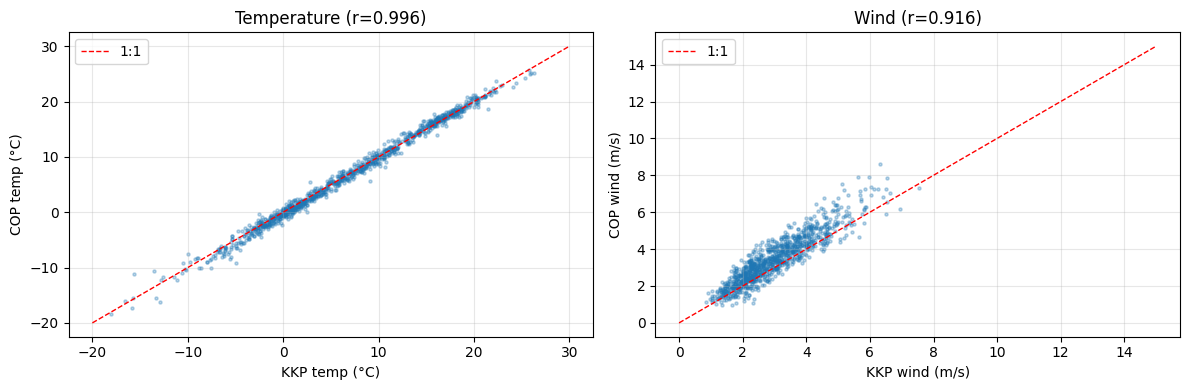

In [36]:
# Merge on date for direct comparison
common = daily_kkp[["date", "T_out_c", "wind_ms"]].merge(
    daily_cop[["date", "T_out_c", "wind_ms"]],
    on="date", suffixes=("_kkp", "_cop")
)

print(f"\nWeather comparison stats (n={len(common)} days):")
print(f"Temperature: corr={common['T_out_c_kkp'].corr(common['T_out_c_cop']):.3f}, "
      f"bias={common['T_out_c_cop'].mean() - common['T_out_c_kkp'].mean():.2f} °C, "
      f"RMSE={np.sqrt(mean_squared_error(common['T_out_c_kkp'], common['T_out_c_cop'])):.2f} °C")
print(f"Wind speed:  corr={common['wind_ms_kkp'].corr(common['wind_ms_cop']):.3f}, "
      f"bias={common['wind_ms_cop'].mean() - common['wind_ms_kkp'].mean():.2f} m/s, "
      f"RMSE={np.sqrt(mean_squared_error(common['wind_ms_kkp'], common['wind_ms_cop'])):.2f} m/s")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(common["T_out_c_kkp"], common["T_out_c_cop"], alpha=0.3, s=5)
ax1.plot([-20, 30], [-20, 30], "r--", lw=1, label="1:1")
ax1.set_xlabel("KKP temp (°C)")
ax1.set_ylabel("COP temp (°C)")
ax1.set_title(f"Temperature (r={common['T_out_c_kkp'].corr(common['T_out_c_cop']):.3f})")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(common["wind_ms_kkp"], common["wind_ms_cop"], alpha=0.3, s=5)
ax2.plot([0, 15], [0, 15], "r--", lw=1, label="1:1")
ax2.set_xlabel("KKP wind (m/s)")
ax2.set_ylabel("COP wind (m/s)")
ax2.set_title(f"Wind (r={common['wind_ms_kkp'].corr(common['wind_ms_cop']):.3f})")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# ES Model Fitting: Three Tiers

## Tier 1a: ES v1 — Temp + Wind Only (Fair Comparison)

$$
\Phi(t) = UA \cdot (T_{base} - T_{out}(t)) + \beta_{wind} \cdot W(t) + \Phi_{base}
$$

**No solar term** — this allows fair comparison between KKP and COP.

Simplification: Fix T_base = 15°C, fit as linear regression.

In [37]:
# ES v1a: KKP (temp + wind only, no solar)
T_base = 15.0
daily_kkp["dT"] = T_base - daily_kkp["T_out_c"]
X_kkp_v1a = daily_kkp[["dT", "wind_ms"]]
y_kkp = daily_kkp["Phi_kWh"]
lm_kkp_v1a = LinearRegression().fit(X_kkp_v1a, y_kkp)
daily_kkp["pred_v1a"] = lm_kkp_v1a.predict(X_kkp_v1a)
r2_kkp_v1a = r2_score(y_kkp, daily_kkp["pred_v1a"])
rmse_kkp_v1a = np.sqrt(mean_squared_error(y_kkp, daily_kkp["pred_v1a"]))
UA_kkp_v1a, beta_wind_kkp_v1a = lm_kkp_v1a.coef_
Phi_base_kkp_v1a = lm_kkp_v1a.intercept_

print("=== ES v1a: KKP (temp + wind only) ===")
print(f"UA = {UA_kkp_v1a:.2f} kW/K")
print(f"β_wind = {beta_wind_kkp_v1a:.2f} kW/(m/s)")
print(f"Φ_base = {Phi_base_kkp_v1a:.2f} kWh")
print(f"T_base = {T_base} °C")
print(f"R² = {r2_kkp_v1a:.3f}, RMSE = {rmse_kkp_v1a:.1f} kWh")

=== ES v1a: KKP (temp + wind only) ===
UA = 279.82 kW/K
β_wind = 48.27 kW/(m/s)
Φ_base = 619.65 kWh
T_base = 15.0 °C
R² = 0.687, RMSE = 1578.6 kWh


In [38]:
# ES v1a: COP (temp + wind only, no solar)
daily_cop["dT"] = T_base - daily_cop["T_out_c"]
X_cop_v1a = daily_cop[["dT", "wind_ms"]]
y_cop = daily_cop["Phi_kWh"]
lm_cop_v1a = LinearRegression().fit(X_cop_v1a, y_cop)
daily_cop["pred_v1a"] = lm_cop_v1a.predict(X_cop_v1a)
r2_cop_v1a = r2_score(y_cop, daily_cop["pred_v1a"])
rmse_cop_v1a = np.sqrt(mean_squared_error(y_cop, daily_cop["pred_v1a"]))
UA_cop_v1a, beta_wind_cop_v1a = lm_cop_v1a.coef_
Phi_base_cop_v1a = lm_cop_v1a.intercept_

print("=== ES v1a: COP (temp + wind only) ===")
print(f"UA = {UA_cop_v1a:.2f} kW/K")
print(f"β_wind = {beta_wind_cop_v1a:.2f} kW/(m/s)")
print(f"Φ_base = {Phi_base_cop_v1a:.2f} kWh")
print(f"T_base = {T_base} °C")
print(f"R² = {r2_cop_v1a:.3f}, RMSE = {rmse_cop_v1a:.1f} kWh")

print(f"\n=== Direct Comparison (v1a: temp+wind only) ===")
print(f"ΔR² = {r2_cop_v1a - r2_kkp_v1a:.4f} ({(r2_cop_v1a/r2_kkp_v1a - 1)*100:+.1f}%)")
print(f"ΔRMSE = {rmse_cop_v1a - rmse_kkp_v1a:.1f} kWh ({(rmse_cop_v1a/rmse_kkp_v1a - 1)*100:+.1f}%)")
print(f"ΔUA = {UA_cop_v1a - UA_kkp_v1a:.2f} kW/K ({(UA_cop_v1a/UA_kkp_v1a - 1)*100:+.1f}%)")
print(f"Δβ_wind = {beta_wind_cop_v1a - beta_wind_kkp_v1a:.2f} kW/(m/s) ({(beta_wind_cop_v1a/beta_wind_kkp_v1a - 1)*100:+.1f}%)")

=== ES v1a: COP (temp + wind only) ===
UA = 268.44 kW/K
β_wind = 1.48 kW/(m/s)
Φ_base = 757.70 kWh
T_base = 15.0 °C
R² = 0.661, RMSE = 1638.5 kWh

=== Direct Comparison (v1a: temp+wind only) ===
ΔR² = -0.0259 (-3.8%)
ΔRMSE = 59.9 kWh (+3.8%)
ΔUA = -11.37 kW/K (-4.1%)
Δβ_wind = -46.79 kW/(m/s) (-96.9%)


---
## Tier 1b: ES v1 + Solar (COP only)

Now add solar irradiance to COP model to show improvement. This matches Smertinas' approach.

$$
\Phi(t) = UA \cdot (T_{base} - T_{out}(t)) + \beta_{wind} \cdot W(t) - \beta_{solar} \cdot I_g(t) + \Phi_{base}
$$

where $I_g$ is global solar irradiance in W/m².

In [39]:
# ES v1b: COP (temp + wind + solar irradiance)
X_cop_v1b = daily_cop[["dT", "wind_ms", "solar_W_per_m2"]]
lm_cop_v1b = LinearRegression().fit(X_cop_v1b, y_cop)
daily_cop["pred_v1b"] = lm_cop_v1b.predict(X_cop_v1b)
r2_cop_v1b = r2_score(y_cop, daily_cop["pred_v1b"])
rmse_cop_v1b = np.sqrt(mean_squared_error(y_cop, daily_cop["pred_v1b"]))
UA_cop_v1b, beta_wind_cop_v1b, beta_solar_cop = lm_cop_v1b.coef_
Phi_base_cop_v1b = lm_cop_v1b.intercept_

print("=== ES v1b: COP (temp + wind + solar) ===")
print(f"UA = {UA_cop_v1b:.2f} kW/K")
print(f"β_wind = {beta_wind_cop_v1b:.2f} kW/(m/s)")
print(f"β_solar = {-beta_solar_cop:.3f} kW/(W/m²)  [negative = solar gain reduces demand]")
print(f"Φ_base = {Phi_base_cop_v1b:.2f} kWh")
print(f"R² = {r2_cop_v1b:.3f}, RMSE = {rmse_cop_v1b:.1f} kWh")

print(f"\n=== Solar Benefit (COP v1b vs v1a) ===")
print(f"ΔR² = {r2_cop_v1b - r2_cop_v1a:.4f} (adding solar improves R² by {(r2_cop_v1b - r2_cop_v1a)*100:.2f} percentage points)")
print(f"ΔRMSE = {rmse_cop_v1a - rmse_cop_v1b:.1f} kWh (adding solar reduces RMSE by {((rmse_cop_v1a - rmse_cop_v1b)/rmse_cop_v1a)*100:.1f}%)")

=== ES v1b: COP (temp + wind + solar) ===
UA = 254.43 kW/K
β_wind = -22.07 kW/(m/s)
β_solar = 1.888 kW/(W/m²)  [negative = solar gain reduces demand]
Φ_base = 1165.39 kWh
R² = 0.664, RMSE = 1632.8 kWh

=== Solar Benefit (COP v1b vs v1a) ===
ΔR² = 0.0024 (adding solar improves R² by 0.24 percentage points)
ΔRMSE = 5.7 kWh (adding solar reduces RMSE by 0.3%)


---
## Tier 2: ARX-ES (Add AR(1) lag)

$$
\Phi(t) = \text{ES terms} + \rho \cdot \Phi(t-1) + \varepsilon(t)
$$

Implementation: Add lagged heat demand as an extra feature.

Compare using temp+wind only (fair comparison).

In [40]:
# ARX-ES: KKP (temp + wind + lag, no solar)
daily_kkp["Phi_lag1"] = daily_kkp["Phi_kWh"].shift(1)
X_kkp_arx = daily_kkp[["dT", "wind_ms", "Phi_lag1"]].dropna()
y_kkp_arx = daily_kkp.loc[X_kkp_arx.index, "Phi_kWh"]
lm_kkp_arx = LinearRegression().fit(X_kkp_arx, y_kkp_arx)
pred_kkp_arx = lm_kkp_arx.predict(X_kkp_arx)
r2_kkp_arx = r2_score(y_kkp_arx, pred_kkp_arx)
rmse_kkp_arx = np.sqrt(mean_squared_error(y_kkp_arx, pred_kkp_arx))
UA_kkp_arx, beta_wind_kkp_arx, rho_kkp = lm_kkp_arx.coef_

print("=== ARX-ES: KKP (temp + wind + lag) ===")
print(f"UA = {UA_kkp_arx:.2f} kW/K, β_wind = {beta_wind_kkp_arx:.2f} kW/(m/s), ρ = {rho_kkp:.3f}")
print(f"R² = {r2_kkp_arx:.3f}, RMSE = {rmse_kkp_arx:.1f} kWh")
print(f"Improvement over ES v1a: ΔR² = {r2_kkp_arx - r2_kkp_v1a:.3f}, ΔRMSE = {rmse_kkp_v1a - rmse_kkp_arx:.1f} kWh")

=== ARX-ES: KKP (temp + wind + lag) ===
UA = 79.65 kW/K, β_wind = -36.70 kW/(m/s), ρ = 0.739
R² = 0.878, RMSE = 987.4 kWh
Improvement over ES v1a: ΔR² = 0.190, ΔRMSE = 591.2 kWh


In [41]:
# ARX-ES: COP (temp + wind + lag, no solar)
daily_cop["Phi_lag1"] = daily_cop["Phi_kWh"].shift(1)
X_cop_arx = daily_cop[["dT", "wind_ms", "Phi_lag1"]].dropna()
y_cop_arx = daily_cop.loc[X_cop_arx.index, "Phi_kWh"]
lm_cop_arx = LinearRegression().fit(X_cop_arx, y_cop_arx)
pred_cop_arx = lm_cop_arx.predict(X_cop_arx)
r2_cop_arx = r2_score(y_cop_arx, pred_cop_arx)
rmse_cop_arx = np.sqrt(mean_squared_error(y_cop_arx, pred_cop_arx))
UA_cop_arx, beta_wind_cop_arx, rho_cop = lm_cop_arx.coef_

print("=== ARX-ES: COP (temp + wind + lag) ===")
print(f"UA = {UA_cop_arx:.2f} kW/K, β_wind = {beta_wind_cop_arx:.2f} kW/(m/s), ρ = {rho_cop:.3f}")
print(f"R² = {r2_cop_arx:.3f}, RMSE = {rmse_cop_arx:.1f} kWh")
print(f"Improvement over ES v1a: ΔR² = {r2_cop_arx - r2_cop_v1a:.3f}, ΔRMSE = {rmse_cop_v1a - rmse_cop_arx:.1f} kWh")

=== ARX-ES: COP (temp + wind + lag) ===
UA = 95.14 kW/K, β_wind = -44.65 kW/(m/s), ρ = 0.664
R² = 0.824, RMSE = 1180.2 kWh
Improvement over ES v1a: ΔR² = 0.163, ΔRMSE = 458.3 kWh


In [42]:
# ARX-ES: COP (temp + wind + solar + lag)
X_cop_arx_solar = daily_cop[["dT", "wind_ms", "solar_W_per_m2", "Phi_lag1"]].dropna()
y_cop_arx_solar = daily_cop.loc[X_cop_arx_solar.index, "Phi_kWh"]
lm_cop_arx_solar = LinearRegression().fit(X_cop_arx_solar, y_cop_arx_solar)
pred_cop_arx_solar = lm_cop_arx_solar.predict(X_cop_arx_solar)
r2_cop_arx_solar = r2_score(y_cop_arx_solar, pred_cop_arx_solar)
rmse_cop_arx_solar = np.sqrt(mean_squared_error(y_cop_arx_solar, pred_cop_arx_solar))

print("=== ARX-ES: COP (temp + wind + solar + lag) ===")
print(f"R² = {r2_cop_arx_solar:.3f}, RMSE = {rmse_cop_arx_solar:.1f} kWh")
print(f"Improvement over ARX (no solar): ΔR² = {r2_cop_arx_solar - r2_cop_arx:.3f}")

=== ARX-ES: COP (temp + wind + solar + lag) ===
R² = 0.824, RMSE = 1180.2 kWh
Improvement over ARX (no solar): ΔR² = 0.000


---
## Tier 3: ARMAX-ES (Add MA(3) terms)

$$
\Phi(t) = \text{ARX terms} + \nu_1 \varepsilon(t-1) + \nu_2 \varepsilon(t-2) + \nu_3 \varepsilon(t-3)
$$

Implementation: `ARIMA(1, 0, 3)` with exogenous regressors.

**Requires:** `pip install statsmodels`

In [43]:
# ARMAX-ES: KKP (temp + wind, no solar)
from statsmodels.tsa.arima.model import ARIMA

exog_kkp = daily_kkp[["dT", "wind_ms"]].values
endog_kkp = daily_kkp["Phi_kWh"].values
model_kkp_armax = ARIMA(endog_kkp, exog=exog_kkp, order=(1, 0, 3)).fit()
pred_kkp_armax = model_kkp_armax.fittedvalues
r2_kkp_armax = r2_score(endog_kkp, pred_kkp_armax)
rmse_kkp_armax = np.sqrt(mean_squared_error(endog_kkp, pred_kkp_armax))

print("=== ARMAX-ES: KKP (temp + wind) ===")
print(f"R² = {r2_kkp_armax:.3f}, RMSE = {rmse_kkp_armax:.1f} kWh")
print(f"Improvement over ARX: ΔR² = {r2_kkp_armax - r2_kkp_arx:.3f}, ΔRMSE = {rmse_kkp_arx - rmse_kkp_armax:.1f} kWh")

=== ARMAX-ES: KKP (temp + wind) ===
R² = 0.899, RMSE = 897.2 kWh
Improvement over ARX: ΔR² = 0.021, ΔRMSE = 90.2 kWh


In [44]:
# ARMAX-ES: COP (temp + wind, no solar)
exog_cop = daily_cop[["dT", "wind_ms"]].values
endog_cop = daily_cop["Phi_kWh"].values
model_cop_armax = ARIMA(endog_cop, exog=exog_cop, order=(1, 0, 3)).fit()
pred_cop_armax = model_cop_armax.fittedvalues
r2_cop_armax = r2_score(endog_cop, pred_cop_armax)
rmse_cop_armax = np.sqrt(mean_squared_error(endog_cop, pred_cop_armax))

print("=== ARMAX-ES: COP (temp + wind) ===")
print(f"R² = {r2_cop_armax:.3f}, RMSE = {rmse_cop_armax:.1f} kWh")
print(f"Improvement over ARX: ΔR² = {r2_cop_armax - r2_cop_arx:.3f}, ΔRMSE = {rmse_cop_arx - rmse_cop_armax:.1f} kWh")

=== ARMAX-ES: COP (temp + wind) ===
R² = 0.849, RMSE = 1094.3 kWh
Improvement over ARX: ΔR² = 0.025, ΔRMSE = 85.9 kWh


In [45]:
# ARMAX-ES: COP (temp + wind + solar)
exog_cop_solar = daily_cop[["dT", "wind_ms", "solar_W_per_m2"]].values
model_cop_armax_solar = ARIMA(endog_cop, exog=exog_cop_solar, order=(1, 0, 3)).fit()
pred_cop_armax_solar = model_cop_armax_solar.fittedvalues
r2_cop_armax_solar = r2_score(endog_cop, pred_cop_armax_solar)
rmse_cop_armax_solar = np.sqrt(mean_squared_error(endog_cop, pred_cop_armax_solar))

print("=== ARMAX-ES: COP (temp + wind + solar) ===")
print(f"R² = {r2_cop_armax_solar:.3f}, RMSE = {rmse_cop_armax_solar:.1f} kWh")
print(f"Improvement over ARMAX (no solar): ΔR² = {r2_cop_armax_solar - r2_cop_armax:.3f}")

=== ARMAX-ES: COP (temp + wind + solar) ===
R² = 0.850, RMSE = 1089.8 kWh
Improvement over ARMAX (no solar): ΔR² = 0.001


---
# Comparison Summary

## Main Result: KKP vs COP (Temp + Wind Only)

In [46]:
# Build comparison table (temp + wind only, fair comparison)
comparison_fair = pd.DataFrame({
    "Model": ["ES v1", "ARX-ES", "ARMAX-ES"],
    "KKP R²": [r2_kkp_v1a, r2_kkp_arx, r2_kkp_armax],
    "KKP RMSE": [rmse_kkp_v1a, rmse_kkp_arx, rmse_kkp_armax],
    "COP R²": [r2_cop_v1a, r2_cop_arx, r2_cop_armax],
    "COP RMSE": [rmse_cop_v1a, rmse_cop_arx, rmse_cop_armax],
})
comparison_fair["ΔR² (COP−KKP)"] = comparison_fair["COP R²"] - comparison_fair["KKP R²"]
comparison_fair["Δ%"] = (comparison_fair["ΔR² (COP−KKP)"] / comparison_fair["KKP R²"] * 100).round(1)

print("\n=== U06: KKP vs COP (Temp + Wind Only) ===")
print(comparison_fair.to_string(index=False))
print("\nInterpretation: If ΔR² < 1%, weather sources are equivalent for ES baseline.")
comparison_fair


=== U06: KKP vs COP (Temp + Wind Only) ===
   Model   KKP R²    KKP RMSE   COP R²    COP RMSE  ΔR² (COP−KKP)   Δ%
   ES v1 0.687245 1578.574504 0.661358 1638.475970      -0.025887 -3.8
  ARX-ES 0.877700  987.404559 0.824390 1180.198552      -0.053310 -6.1
ARMAX-ES 0.898960  897.241372 0.848945 1094.301751      -0.050015 -5.6

Interpretation: If ΔR² < 1%, weather sources are equivalent for ES baseline.


,Model,KKP R²,KKP RMSE,COP R²,COP RMSE,ΔR² (COP−KKP),Δ%
0,ES v1,0.687245,1578.574504,0.661358,1638.475970,-0.025887,-3.8
1,ARX-ES,0.877700,987.404559,0.824390,1180.198552,-0.053310,-6.1
2,ARMAX-ES,0.898960,897.241372,0.848945,1094.301751,-0.050015,-5.6


## Solar Benefit: COP Only

In [47]:
# Solar benefit table (COP only)
solar_benefit = pd.DataFrame({
    "Model": ["ES v1", "ARX-ES", "ARMAX-ES"],
    "COP R² (no solar)": [r2_cop_v1a, r2_cop_arx, r2_cop_armax],
    "COP R² (with solar)": [r2_cop_v1b, r2_cop_arx_solar, r2_cop_armax_solar],
    "ΔR² (solar benefit)": [
        r2_cop_v1b - r2_cop_v1a,
        r2_cop_arx_solar - r2_cop_arx,
        r2_cop_armax_solar - r2_cop_armax
    ],
})
solar_benefit["Improvement (%)"] = (solar_benefit["ΔR² (solar benefit)"] * 100).round(2)

print("\n=== Solar Irradiance Benefit (COP only) ===")
print(solar_benefit.to_string(index=False))
print("\nInterpretation: Adding global solar irradiance (W/m²) improves R² by X percentage points.")
solar_benefit


=== Solar Irradiance Benefit (COP only) ===
   Model  COP R² (no solar)  COP R² (with solar)  ΔR² (solar benefit)  Improvement (%)
   ES v1           0.661358             0.663715             0.002357             0.24
  ARX-ES           0.824390             0.824400             0.000010             0.00
ARMAX-ES           0.848945             0.850181             0.001236             0.12

Interpretation: Adding global solar irradiance (W/m²) improves R² by X percentage points.


,Model,COP R² (no solar),COP R² (with solar),ΔR² (solar benefit),Improvement (%)
0,ES v1,0.661358,0.663715,0.002357,0.24
1,ARX-ES,0.824390,0.824400,0.000010,0.00
2,ARMAX-ES,0.848945,0.850181,0.001236,0.12


## Parameter Comparison: ES v1 (Temp + Wind)

In [48]:
params_v1a = pd.DataFrame({
    "Parameter": ["UA (kW/K)", "β_wind (kW/(m/s))", "Φ_base (kWh)"],
    "KKP": [UA_kkp_v1a, beta_wind_kkp_v1a, Phi_base_kkp_v1a],
    "COP": [UA_cop_v1a, beta_wind_cop_v1a, Phi_base_cop_v1a],
})
params_v1a["Δ (COP−KKP)"] = params_v1a["COP"] - params_v1a["KKP"]
params_v1a["Δ%"] = (params_v1a["Δ (COP−KKP)"] / params_v1a["KKP"].replace(0, np.nan) * 100).round(1)

print("\n=== ES v1 Parameters: KKP vs COP (Temp + Wind) ===")
print(params_v1a.to_string(index=False))
print("\nPhysical interpretation:")
print(f"- UA sign: {'✓ Both positive' if UA_kkp_v1a > 0 and UA_cop_v1a > 0 else '✗ Sign mismatch'}")
print(f"- β_wind sign: {'✓ Both same sign' if np.sign(beta_wind_kkp_v1a) == np.sign(beta_wind_cop_v1a) else '✗ Sign flip (multicollinearity issue)'}")
params_v1a


=== ES v1 Parameters: KKP vs COP (Temp + Wind) ===
        Parameter        KKP        COP  Δ (COP−KKP)    Δ%
        UA (kW/K) 279.816750 268.442243   -11.374507  -4.1
β_wind (kW/(m/s))  48.271840   1.477481   -46.794359 -96.9
     Φ_base (kWh) 619.645513 757.700814   138.055302  22.3

Physical interpretation:
- UA sign: ✓ Both positive
- β_wind sign: ✓ Both same sign


,Parameter,KKP,COP,Δ (COP−KKP),Δ%
0,UA (kW/K),279.816750,268.442243,-11.374507,-4.1
1,β_wind (kW/(m/s)),48.271840,1.477481,-46.794359,-96.9
2,Φ_base (kWh),619.645513,757.700814,138.055302,22.3


---
## Diagnostic Plots

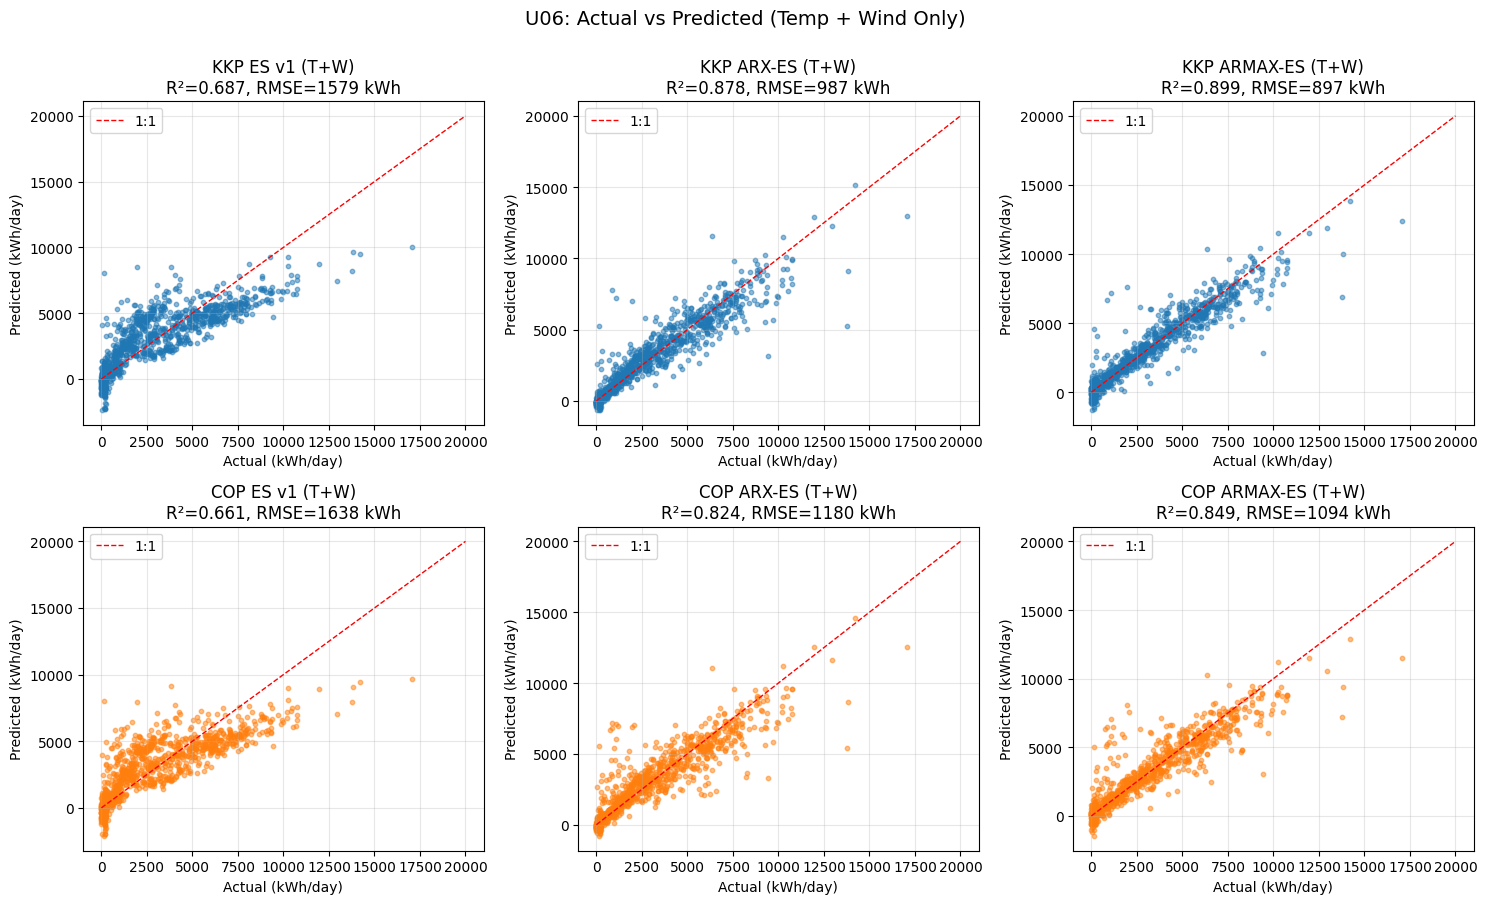

In [49]:
# Actual vs Predicted (all 3 models × 2 sources, temp+wind only)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 1: KKP
for i, (name, pred, actual, r2, rmse) in enumerate([
    ("ES v1", daily_kkp["pred_v1a"], y_kkp, r2_kkp_v1a, rmse_kkp_v1a),
    ("ARX-ES", pred_kkp_arx, y_kkp_arx, r2_kkp_arx, rmse_kkp_arx),
    ("ARMAX-ES", pred_kkp_armax, endog_kkp, r2_kkp_armax, rmse_kkp_armax)
]):
    ax = axes[0, i]
    ax.scatter(actual, pred, alpha=0.5, s=10)
    max_val = 20000
    ax.plot([0, max_val], [0, max_val], "r--", lw=1, label="1:1")
    ax.set_xlabel("Actual (kWh/day)")
    ax.set_ylabel("Predicted (kWh/day)")
    ax.set_title(f"KKP {name} (T+W)\nR²={r2:.3f}, RMSE={rmse:.0f} kWh")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Row 2: COP
for i, (name, pred, actual, r2, rmse) in enumerate([
    ("ES v1", daily_cop["pred_v1a"], y_cop, r2_cop_v1a, rmse_cop_v1a),
    ("ARX-ES", pred_cop_arx, y_cop_arx, r2_cop_arx, rmse_cop_arx),
    ("ARMAX-ES", pred_cop_armax, endog_cop, r2_cop_armax, rmse_cop_armax)
]):
    ax = axes[1, i]
    ax.scatter(actual, pred, alpha=0.5, s=10, color="C1")
    max_val = 20000
    ax.plot([0, max_val], [0, max_val], "r--", lw=1, label="1:1")
    ax.set_xlabel("Actual (kWh/day)")
    ax.set_ylabel("Predicted (kWh/day)")
    ax.set_title(f"COP {name} (T+W)\nR²={r2:.3f}, RMSE={rmse:.0f} kWh")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("U06: Actual vs Predicted (Temp + Wind Only)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

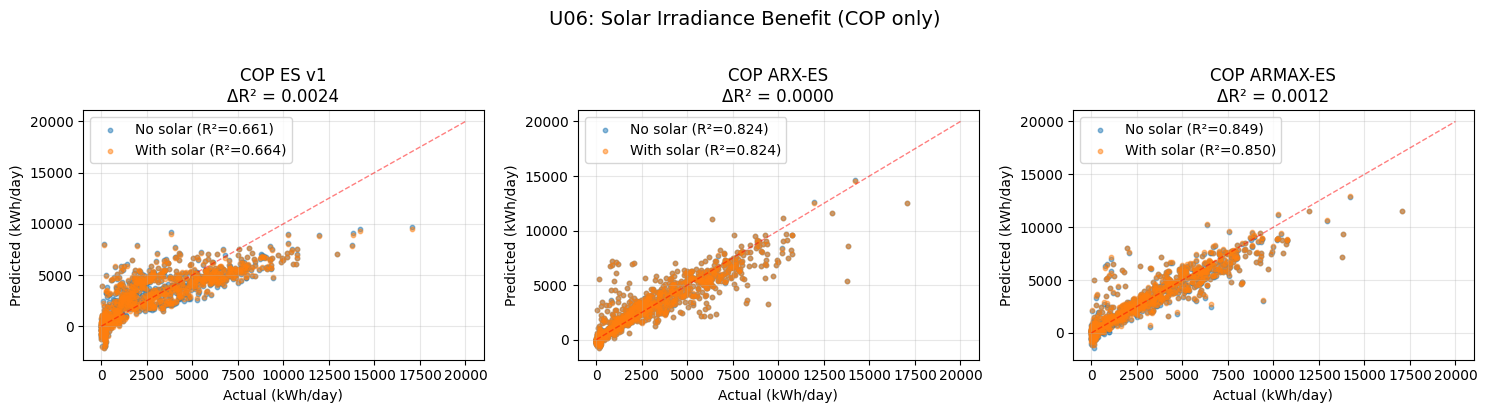

In [50]:
# Solar benefit visualization (COP only)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, pred_no_solar, pred_with_solar, r2_no, r2_with) in enumerate([
    ("ES v1", daily_cop["pred_v1a"], daily_cop["pred_v1b"], r2_cop_v1a, r2_cop_v1b),
    ("ARX-ES", pred_cop_arx, pred_cop_arx_solar, r2_cop_arx, r2_cop_arx_solar),
    ("ARMAX-ES", pred_cop_armax, pred_cop_armax_solar, r2_cop_armax, r2_cop_armax_solar)
]):
    ax = axes[i]
    ax.scatter(y_cop if i == 0 else (y_cop_arx if i == 1 else endog_cop), 
               pred_no_solar, alpha=0.5, s=10, label=f"No solar (R²={r2_no:.3f})")
    ax.scatter(y_cop if i == 0 else (y_cop_arx_solar if i == 1 else endog_cop), 
               pred_with_solar, alpha=0.5, s=10, label=f"With solar (R²={r2_with:.3f})")
    max_val = 20000
    ax.plot([0, max_val], [0, max_val], "r--", lw=1, alpha=0.5)
    ax.set_xlabel("Actual (kWh/day)")
    ax.set_ylabel("Predicted (kWh/day)")
    ax.set_title(f"COP {name}\nΔR² = {r2_with - r2_no:.4f}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("U06: Solar Irradiance Benefit (COP only)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

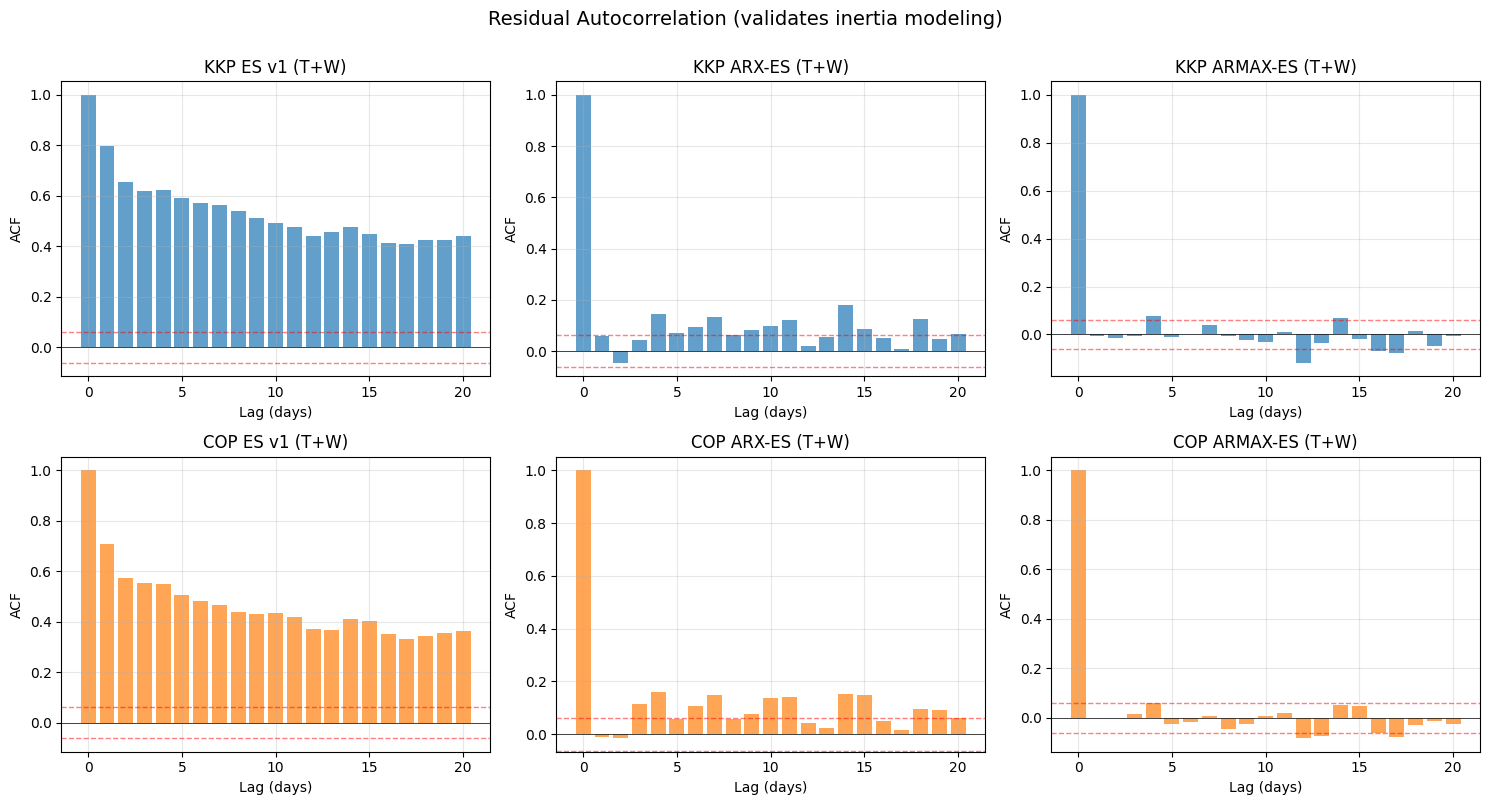

In [51]:
# Residual ACF (Autocorrelation Function)
# Check if lags reduce residual autocorrelation (validates inertia modeling)
residuals = {
    "KKP ES v1": y_kkp - daily_kkp["pred_v1a"],
    "KKP ARX-ES": y_kkp_arx - pred_kkp_arx,
    "KKP ARMAX-ES": pd.Series(endog_kkp - pred_kkp_armax),
    "COP ES v1": y_cop - daily_cop["pred_v1a"],
    "COP ARX-ES": y_cop_arx - pred_cop_arx,
    "COP ARMAX-ES": pd.Series(endog_cop - pred_cop_armax),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, (name, res) in enumerate(residuals.items()):
    ax = axes[i]
    res_clean = res.dropna()
    acf_vals = acf(res_clean, nlags=20, fft=False)
    ax.bar(range(21), acf_vals, color="C0" if "KKP" in name else "C1", alpha=0.7)
    ax.axhline(0, color="k", lw=0.5)
    # 95% confidence bands
    n = len(res_clean)
    ci = 1.96 / np.sqrt(n)
    ax.axhline(ci, color="r", ls="--", lw=1, alpha=0.5)
    ax.axhline(-ci, color="r", ls="--", lw=1, alpha=0.5)
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("ACF")
    ax.set_title(f"{name} (T+W)")
    ax.grid(True, alpha=0.3)
plt.suptitle("Residual Autocorrelation (validates inertia modeling)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


---
# Heating Season Analysis (Oct–Apr)

## Why this matters

The all-days analysis above includes **summer days** where heating demand is near-zero but solar irradiance is high. These low-demand days dilute the solar signal: there's plenty of sun, but almost no heating to predict, so solar irradiance can't improve the model.

At **59°N (Tallinn)**, winter solar irradiance is very weak:
- **January**: ~13 W/m² daily mean
- **December**: ~8 W/m²
- **October–April** (heating season): ~55 W/m² mean

Additionally, solar irradiance is **correlated with temperature** (r ≈ -0.29 with ΔT in heating season) — sunny days tend to be warmer, so temperature already partially captures the solar effect.

To isolate the solar benefit where it actually matters, we repeat the full three-tier analysis on **heating season only (October–April)**.

In [52]:
# ── Heating Season Filter (October–April) ──
HEATING_MONTHS = [1, 2, 3, 4, 10, 11, 12]

hs_kkp = daily_kkp[daily_kkp["datetime"].dt.month.isin(HEATING_MONTHS)].copy().reset_index(drop=True)
hs_cop = daily_cop[daily_cop["datetime"].dt.month.isin(HEATING_MONTHS)].copy().reset_index(drop=True)

print(f"All-days → KKP: {len(daily_kkp)} days, COP: {len(daily_cop)} days")
print(f"Heating season (Oct–Apr) → KKP: {len(hs_kkp)} days, COP: {len(hs_cop)} days")
print(f"\nHeating season solar stats (COP):")
print(f"  Mean:  {hs_cop['solar_W_per_m2'].mean():.1f} W/m²")
print(f"  Std:   {hs_cop['solar_W_per_m2'].std():.1f} W/m²")
print(f"  Range: {hs_cop['solar_W_per_m2'].min():.1f} – {hs_cop['solar_W_per_m2'].max():.1f} W/m²")
print(f"\nHeating season Φ stats:")
print(f"  KKP mean: {hs_kkp['Phi_kWh'].mean():.0f} kWh/day")
print(f"  COP mean: {hs_cop['Phi_kWh'].mean():.0f} kWh/day")

# Correlations in heating season
hs_corr = hs_cop[["dT", "wind_ms", "solar_W_per_m2", "Phi_kWh"]].corr()
print(f"\nCorrelation matrix (heating season, COP):")
print(hs_corr.round(3).to_string())

All-days → KKP: 1007 days, COP: 1007 days
Heating season (Oct–Apr) → KKP: 609 days, COP: 609 days

Heating season solar stats (COP):
  Mean:  55.4 W/m²
  Std:   61.2 W/m²
  Range: 0.0 – 247.6 W/m²

Heating season Φ stats:
  KKP mean: 4508 kWh/day
  COP mean: 4403 kWh/day

Correlation matrix (heating season, COP):
                   dT  wind_ms  solar_W_per_m2  Phi_kWh
dT              1.000   -0.230          -0.292    0.664
wind_ms        -0.230    1.000          -0.129   -0.087
solar_W_per_m2 -0.292   -0.129           1.000   -0.300
Phi_kWh         0.664   -0.087          -0.300    1.000


## Heating Season: Tier 1 – ES v1

In [53]:
# ── Heating Season: ES v1a (temp + wind only) ──

# KKP
hs_kkp["dT"] = T_base - hs_kkp["T_out_c"]
X_hs_kkp_v1a = hs_kkp[["dT", "wind_ms"]]
y_hs_kkp = hs_kkp["Phi_kWh"]
lm_hs_kkp_v1a = LinearRegression().fit(X_hs_kkp_v1a, y_hs_kkp)
hs_kkp["pred_v1a"] = lm_hs_kkp_v1a.predict(X_hs_kkp_v1a)
r2_hs_kkp_v1a = r2_score(y_hs_kkp, hs_kkp["pred_v1a"])
rmse_hs_kkp_v1a = np.sqrt(mean_squared_error(y_hs_kkp, hs_kkp["pred_v1a"]))

# COP (no solar)
hs_cop["dT"] = T_base - hs_cop["T_out_c"]
X_hs_cop_v1a = hs_cop[["dT", "wind_ms"]]
y_hs_cop = hs_cop["Phi_kWh"]
lm_hs_cop_v1a = LinearRegression().fit(X_hs_cop_v1a, y_hs_cop)
hs_cop["pred_v1a"] = lm_hs_cop_v1a.predict(X_hs_cop_v1a)
r2_hs_cop_v1a = r2_score(y_hs_cop, hs_cop["pred_v1a"])
rmse_hs_cop_v1a = np.sqrt(mean_squared_error(y_hs_cop, hs_cop["pred_v1a"]))

# COP (with solar)
X_hs_cop_v1b = hs_cop[["dT", "wind_ms", "solar_W_per_m2"]]
lm_hs_cop_v1b = LinearRegression().fit(X_hs_cop_v1b, y_hs_cop)
hs_cop["pred_v1b"] = lm_hs_cop_v1b.predict(X_hs_cop_v1b)
r2_hs_cop_v1b = r2_score(y_hs_cop, hs_cop["pred_v1b"])
rmse_hs_cop_v1b = np.sqrt(mean_squared_error(y_hs_cop, hs_cop["pred_v1b"]))
beta_solar_hs_v1 = lm_hs_cop_v1b.coef_[2]

print("=== Heating Season: ES v1 ===")
print(f"KKP (T+W):        R² = {r2_hs_kkp_v1a:.4f}, RMSE = {rmse_hs_kkp_v1a:.0f} kWh")
print(f"COP (T+W):        R² = {r2_hs_cop_v1a:.4f}, RMSE = {rmse_hs_cop_v1a:.0f} kWh")
print(f"COP (T+W+Solar):  R² = {r2_hs_cop_v1b:.4f}, RMSE = {rmse_hs_cop_v1b:.0f} kWh")
print(f"\nΔR² KKP vs COP (T+W): {r2_hs_cop_v1a - r2_hs_kkp_v1a:.4f}")
print(f"ΔR² solar benefit:    {r2_hs_cop_v1b - r2_hs_cop_v1a:.4f}  (vs all-days: {r2_cop_v1b - r2_cop_v1a:.4f})")
print(f"β_solar = {beta_solar_hs_v1:.2f} kWh/(W/m²)/day  {'✓ negative (correct)' if beta_solar_hs_v1 < 0 else '✗ positive (unexpected)'}")

=== Heating Season: ES v1 ===
KKP (T+W):        R² = 0.4794, RMSE = 1897 kWh
COP (T+W):        R² = 0.4448, RMSE = 1987 kWh
COP (T+W+Solar):  R² = 0.4545, RMSE = 1970 kWh

ΔR² KKP vs COP (T+W): -0.0346
ΔR² solar benefit:    0.0097  (vs all-days: 0.0024)
β_solar = -4.59 kWh/(W/m²)/day  ✓ negative (correct)


## Heating Season: Tier 2 – ARX-ES

In [54]:
# ── Heating Season: ARX-ES ──

# KKP (temp + wind + lag)
hs_kkp["Phi_lag1"] = hs_kkp["Phi_kWh"].shift(1)
X_hs_kkp_arx = hs_kkp[["dT", "wind_ms", "Phi_lag1"]].dropna()
y_hs_kkp_arx = hs_kkp.loc[X_hs_kkp_arx.index, "Phi_kWh"]
lm_hs_kkp_arx = LinearRegression().fit(X_hs_kkp_arx, y_hs_kkp_arx)
pred_hs_kkp_arx = lm_hs_kkp_arx.predict(X_hs_kkp_arx)
r2_hs_kkp_arx = r2_score(y_hs_kkp_arx, pred_hs_kkp_arx)
rmse_hs_kkp_arx = np.sqrt(mean_squared_error(y_hs_kkp_arx, pred_hs_kkp_arx))

# COP (temp + wind + lag, no solar)
hs_cop["Phi_lag1"] = hs_cop["Phi_kWh"].shift(1)
X_hs_cop_arx = hs_cop[["dT", "wind_ms", "Phi_lag1"]].dropna()
y_hs_cop_arx = hs_cop.loc[X_hs_cop_arx.index, "Phi_kWh"]
lm_hs_cop_arx = LinearRegression().fit(X_hs_cop_arx, y_hs_cop_arx)
pred_hs_cop_arx = lm_hs_cop_arx.predict(X_hs_cop_arx)
r2_hs_cop_arx = r2_score(y_hs_cop_arx, pred_hs_cop_arx)
rmse_hs_cop_arx = np.sqrt(mean_squared_error(y_hs_cop_arx, pred_hs_cop_arx))

# COP (temp + wind + solar + lag)
X_hs_cop_arx_s = hs_cop[["dT", "wind_ms", "solar_W_per_m2", "Phi_lag1"]].dropna()
y_hs_cop_arx_s = hs_cop.loc[X_hs_cop_arx_s.index, "Phi_kWh"]
lm_hs_cop_arx_s = LinearRegression().fit(X_hs_cop_arx_s, y_hs_cop_arx_s)
pred_hs_cop_arx_s = lm_hs_cop_arx_s.predict(X_hs_cop_arx_s)
r2_hs_cop_arx_s = r2_score(y_hs_cop_arx_s, pred_hs_cop_arx_s)
rmse_hs_cop_arx_s = np.sqrt(mean_squared_error(y_hs_cop_arx_s, pred_hs_cop_arx_s))

print("=== Heating Season: ARX-ES ===")
print(f"KKP (T+W+lag):        R² = {r2_hs_kkp_arx:.4f}, RMSE = {rmse_hs_kkp_arx:.0f} kWh")
print(f"COP (T+W+lag):        R² = {r2_hs_cop_arx:.4f}, RMSE = {rmse_hs_cop_arx:.0f} kWh")
print(f"COP (T+W+S+lag):      R² = {r2_hs_cop_arx_s:.4f}, RMSE = {rmse_hs_cop_arx_s:.0f} kWh")
print(f"\nΔR² KKP vs COP (T+W): {r2_hs_cop_arx - r2_hs_kkp_arx:.4f}")
print(f"ΔR² solar benefit:    {r2_hs_cop_arx_s - r2_hs_cop_arx:.4f}  (vs all-days: {r2_cop_arx_solar - r2_cop_arx:.4f})")

=== Heating Season: ARX-ES ===
KKP (T+W+lag):        R² = 0.7836, RMSE = 1224 kWh
COP (T+W+lag):        R² = 0.6971, RMSE = 1469 kWh
COP (T+W+S+lag):      R² = 0.6974, RMSE = 1468 kWh

ΔR² KKP vs COP (T+W): -0.0865
ΔR² solar benefit:    0.0003  (vs all-days: 0.0000)


## Heating Season: Tier 3 – ARMAX-ES

In [55]:
# ── Heating Season: ARMAX-ES ──
import warnings

# KKP (temp + wind)
exog_hs_kkp = hs_kkp[["dT", "wind_ms"]].values
endog_hs_kkp = hs_kkp["Phi_kWh"].values
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_hs_kkp_armax = ARIMA(endog_hs_kkp, exog=exog_hs_kkp, order=(1, 0, 3)).fit()
pred_hs_kkp_armax = model_hs_kkp_armax.fittedvalues
r2_hs_kkp_armax = r2_score(endog_hs_kkp, pred_hs_kkp_armax)
rmse_hs_kkp_armax = np.sqrt(mean_squared_error(endog_hs_kkp, pred_hs_kkp_armax))

# COP (temp + wind, no solar)
exog_hs_cop = hs_cop[["dT", "wind_ms"]].values
endog_hs_cop = hs_cop["Phi_kWh"].values
model_hs_cop_armax = ARIMA(endog_hs_cop, exog=exog_hs_cop, order=(1, 0, 3)).fit()
pred_hs_cop_armax = model_hs_cop_armax.fittedvalues
r2_hs_cop_armax = r2_score(endog_hs_cop, pred_hs_cop_armax)
rmse_hs_cop_armax = np.sqrt(mean_squared_error(endog_hs_cop, pred_hs_cop_armax))

# COP (temp + wind + solar)
exog_hs_cop_s = hs_cop[["dT", "wind_ms", "solar_W_per_m2"]].values
model_hs_cop_armax_s = ARIMA(endog_hs_cop, exog=exog_hs_cop_s, order=(1, 0, 3)).fit()
pred_hs_cop_armax_s = model_hs_cop_armax_s.fittedvalues
r2_hs_cop_armax_s = r2_score(endog_hs_cop, pred_hs_cop_armax_s)
rmse_hs_cop_armax_s = np.sqrt(mean_squared_error(endog_hs_cop, pred_hs_cop_armax_s))

print("=== Heating Season: ARMAX-ES ===")
print(f"KKP (T+W):        R² = {r2_hs_kkp_armax:.4f}, RMSE = {rmse_hs_kkp_armax:.0f} kWh")
print(f"COP (T+W):        R² = {r2_hs_cop_armax:.4f}, RMSE = {rmse_hs_cop_armax:.0f} kWh")
print(f"COP (T+W+Solar):  R² = {r2_hs_cop_armax_s:.4f}, RMSE = {rmse_hs_cop_armax_s:.0f} kWh")
print(f"\nΔR² KKP vs COP (T+W): {r2_hs_cop_armax - r2_hs_kkp_armax:.4f}")
print(f"ΔR² solar benefit:    {r2_hs_cop_armax_s - r2_hs_cop_armax:.4f}  (vs all-days: {r2_cop_armax_solar - r2_cop_armax:.4f})")

=== Heating Season: ARMAX-ES ===
KKP (T+W):        R² = 0.8308, RMSE = 1081 kWh
COP (T+W):        R² = 0.7443, RMSE = 1349 kWh
COP (T+W+Solar):  R² = 0.7455, RMSE = 1346 kWh

ΔR² KKP vs COP (T+W): -0.0865
ΔR² solar benefit:    0.0013  (vs all-days: 0.0012)


---
## All-Days vs Heating Season: Combined Comparison

Side-by-side tables showing how the period affects both the KKP vs COP comparison and the solar irradiance benefit.

In [56]:
# ── Combined comparison: All-Days vs Heating Season ──

# --- Table 1: KKP vs COP (temp+wind only) ---
print("=" * 90)
print("TABLE 1: KKP vs COP Weather Source Comparison (Temp + Wind Only)")
print("=" * 90)
rows = []
for period, data in [("All days", {
        "ES v1": (r2_kkp_v1a, rmse_kkp_v1a, r2_cop_v1a, rmse_cop_v1a),
        "ARX-ES": (r2_kkp_arx, rmse_kkp_arx, r2_cop_arx, rmse_cop_arx),
        "ARMAX-ES": (r2_kkp_armax, rmse_kkp_armax, r2_cop_armax, rmse_cop_armax),
    }), ("Heating (Oct–Apr)", {
        "ES v1": (r2_hs_kkp_v1a, rmse_hs_kkp_v1a, r2_hs_cop_v1a, rmse_hs_cop_v1a),
        "ARX-ES": (r2_hs_kkp_arx, rmse_hs_kkp_arx, r2_hs_cop_arx, rmse_hs_cop_arx),
        "ARMAX-ES": (r2_hs_kkp_armax, rmse_hs_kkp_armax, r2_hs_cop_armax, rmse_hs_cop_armax),
    })]:
    for model, (r2k, rk, r2c, rc) in data.items():
        rows.append({
            "Period": period, "Model": model,
            "KKP R²": round(r2k, 4), "KKP RMSE": round(rk, 0),
            "COP R²": round(r2c, 4), "COP RMSE": round(rc, 0),
            "ΔR²": round(r2c - r2k, 4),
        })
table1 = pd.DataFrame(rows)
print(table1.to_string(index=False))

# --- Table 2: Solar Irradiance Benefit (COP only) ---
print("\n")
print("=" * 90)
print("TABLE 2: Solar Irradiance Benefit — All Days vs Heating Season (COP only)")
print("=" * 90)
rows2 = []
for period, data in [("All days", {
        "ES v1": (r2_cop_v1a, r2_cop_v1b),
        "ARX-ES": (r2_cop_arx, r2_cop_arx_solar),
        "ARMAX-ES": (r2_cop_armax, r2_cop_armax_solar),
    }), ("Heating (Oct–Apr)", {
        "ES v1": (r2_hs_cop_v1a, r2_hs_cop_v1b),
        "ARX-ES": (r2_hs_cop_arx, r2_hs_cop_arx_s),
        "ARMAX-ES": (r2_hs_cop_armax, r2_hs_cop_armax_s),
    })]:
    for model, (r2_no, r2_yes) in data.items():
        dr2 = r2_yes - r2_no
        rows2.append({
            "Period": period, "Model": model,
            "R² (no solar)": round(r2_no, 4),
            "R² (with solar)": round(r2_yes, 4),
            "ΔR² (solar)": round(dr2, 4),
            "× improvement": f"{dr2 / max(r2_cop_v1b - r2_cop_v1a, 1e-9):.1f}×" if period != "All days" else "baseline",
        })
table2 = pd.DataFrame(rows2)
print(table2.to_string(index=False))

print("\n─── Key takeaway ───")
hs_v1_solar = r2_hs_cop_v1b - r2_hs_cop_v1a
ad_v1_solar = r2_cop_v1b - r2_cop_v1a
print(f"ES v1 solar ΔR²:  all-days = {ad_v1_solar:.4f}  →  heating season = {hs_v1_solar:.4f}  ({hs_v1_solar/max(ad_v1_solar,1e-9):.1f}× larger)")
hs_armax_solar = r2_hs_cop_armax_s - r2_hs_cop_armax
ad_armax_solar = r2_cop_armax_solar - r2_cop_armax
print(f"ARMAX solar ΔR²:  all-days = {ad_armax_solar:.4f}  →  heating season = {hs_armax_solar:.4f}  ({hs_armax_solar/max(ad_armax_solar,1e-9):.1f}× larger)")

TABLE 1: KKP vs COP Weather Source Comparison (Temp + Wind Only)
           Period    Model  KKP R²  KKP RMSE  COP R²  COP RMSE     ΔR²
         All days    ES v1  0.6872    1579.0  0.6614    1638.0 -0.0259
         All days   ARX-ES  0.8777     987.0  0.8244    1180.0 -0.0533
         All days ARMAX-ES  0.8990     897.0  0.8489    1094.0 -0.0500
Heating (Oct–Apr)    ES v1  0.4794    1897.0  0.4448    1987.0 -0.0346
Heating (Oct–Apr)   ARX-ES  0.7836    1224.0  0.6971    1469.0 -0.0865
Heating (Oct–Apr) ARMAX-ES  0.8308    1081.0  0.7443    1349.0 -0.0865


TABLE 2: Solar Irradiance Benefit — All Days vs Heating Season (COP only)
           Period    Model  R² (no solar)  R² (with solar)  ΔR² (solar) × improvement
         All days    ES v1         0.6614           0.6637       0.0024      baseline
         All days   ARX-ES         0.8244           0.8244       0.0000      baseline
         All days ARMAX-ES         0.8489           0.8502       0.0012      baseline
Heating (Oct–Apr) 

## Heating Season: Diagnostic Plots

Actual vs predicted for heating season only. Compare to the all-days plots above — the scatter should be tighter since we exclude low-demand summer days that inflate R².

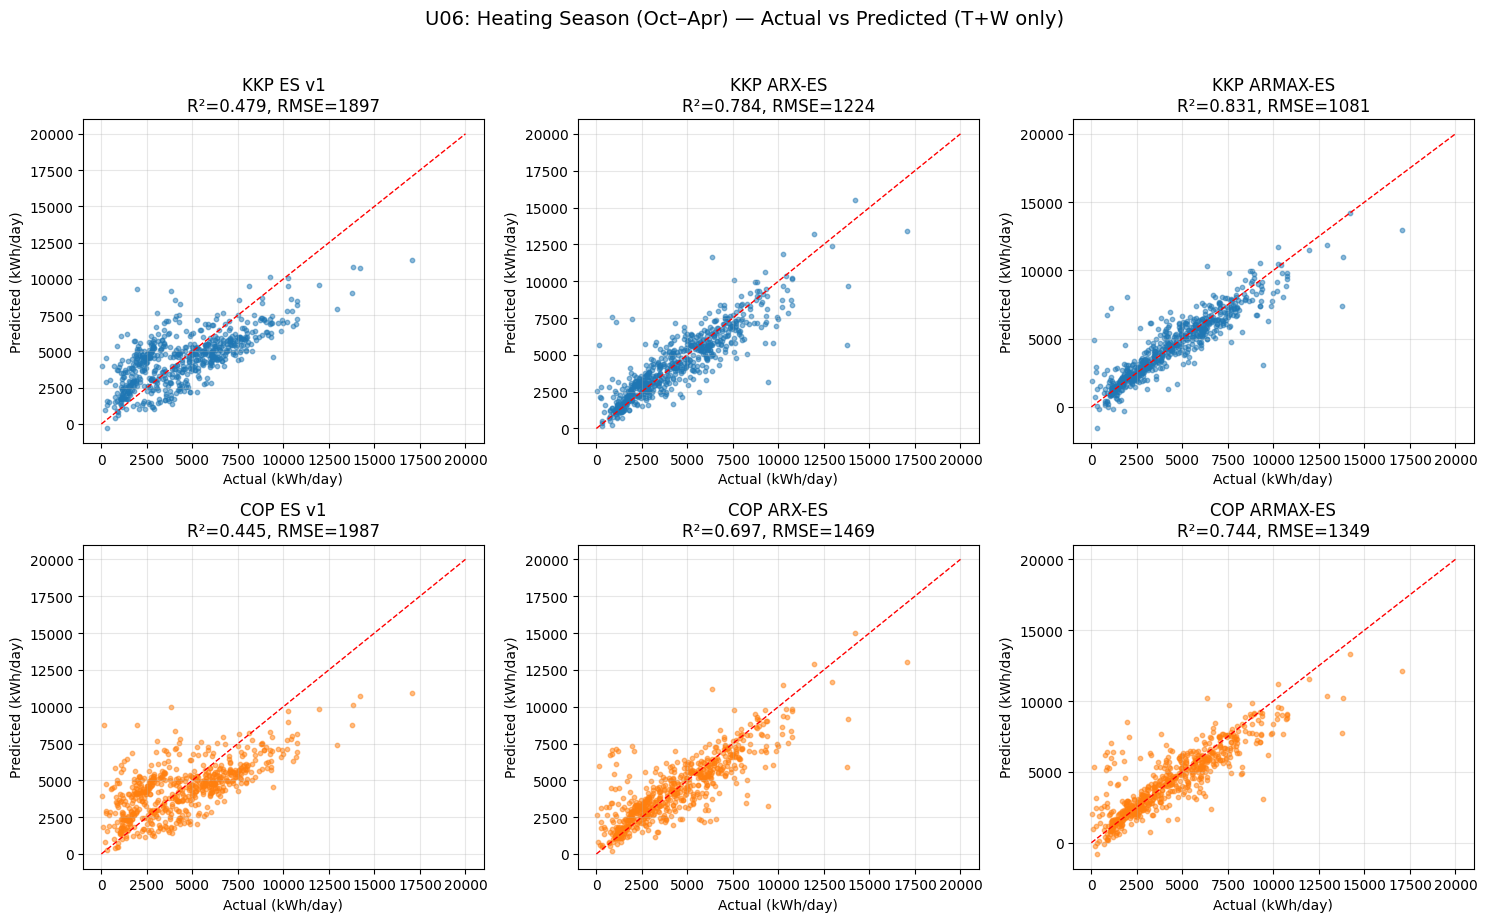

In [57]:
# ── Heating Season: Actual vs Predicted ──
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 1: KKP
for i, (name, pred, actual, r2, rmse) in enumerate([
    ("ES v1", hs_kkp["pred_v1a"], y_hs_kkp, r2_hs_kkp_v1a, rmse_hs_kkp_v1a),
    ("ARX-ES", pred_hs_kkp_arx, y_hs_kkp_arx, r2_hs_kkp_arx, rmse_hs_kkp_arx),
    ("ARMAX-ES", pred_hs_kkp_armax, endog_hs_kkp, r2_hs_kkp_armax, rmse_hs_kkp_armax)
]):
    ax = axes[0, i]
    ax.scatter(actual, pred, alpha=0.5, s=10)
    max_val = 20000
    ax.plot([0, max_val], [0, max_val], "r--", lw=1)
    ax.set_xlabel("Actual (kWh/day)")
    ax.set_ylabel("Predicted (kWh/day)")
    ax.set_title(f"KKP {name}\nR²={r2:.3f}, RMSE={rmse:.0f}")
    ax.grid(True, alpha=0.3)

# Row 2: COP
for i, (name, pred, actual, r2, rmse) in enumerate([
    ("ES v1", hs_cop["pred_v1a"], y_hs_cop, r2_hs_cop_v1a, rmse_hs_cop_v1a),
    ("ARX-ES", pred_hs_cop_arx, y_hs_cop_arx, r2_hs_cop_arx, rmse_hs_cop_arx),
    ("ARMAX-ES", pred_hs_cop_armax, endog_hs_cop, r2_hs_cop_armax, rmse_hs_cop_armax)
]):
    ax = axes[1, i]
    ax.scatter(actual, pred, alpha=0.5, s=10, color="C1")
    ax.plot([0, max_val], [0, max_val], "r--", lw=1)
    ax.set_xlabel("Actual (kWh/day)")
    ax.set_ylabel("Predicted (kWh/day)")
    ax.set_title(f"COP {name}\nR²={r2:.3f}, RMSE={rmse:.0f}")
    ax.grid(True, alpha=0.3)

plt.suptitle("U06: Heating Season (Oct–Apr) — Actual vs Predicted (T+W only)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

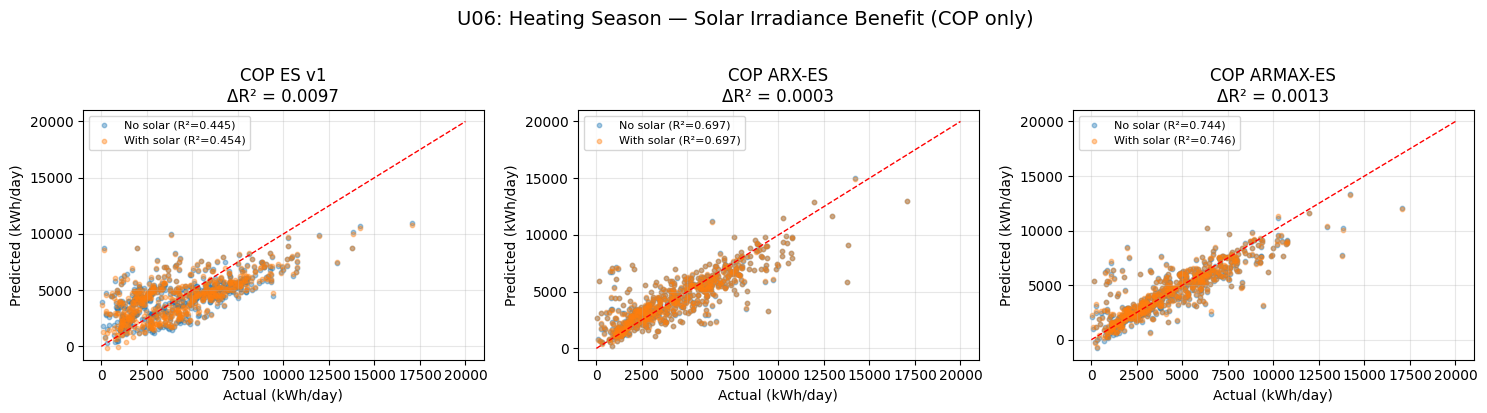

In [58]:
# ── Heating Season: Solar Benefit Plot ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, pred_no, pred_yes, r2_no, r2_yes, actual) in enumerate([
    ("ES v1", hs_cop["pred_v1a"], hs_cop["pred_v1b"],
     r2_hs_cop_v1a, r2_hs_cop_v1b, y_hs_cop),
    ("ARX-ES", pred_hs_cop_arx, pred_hs_cop_arx_s,
     r2_hs_cop_arx, r2_hs_cop_arx_s, y_hs_cop_arx),
    ("ARMAX-ES", pred_hs_cop_armax, pred_hs_cop_armax_s,
     r2_hs_cop_armax, r2_hs_cop_armax_s, endog_hs_cop),
]):
    ax = axes[i]
    ax.scatter(actual, pred_no, alpha=0.4, s=10, label=f"No solar (R²={r2_no:.3f})")
    ax.scatter(actual, pred_yes, alpha=0.4, s=10, label=f"With solar (R²={r2_yes:.3f})")
    max_val = 20000
    ax.plot([0, max_val], [0, max_val], "r--", lw=1)
    ax.set_xlabel("Actual (kWh/day)")
    ax.set_ylabel("Predicted (kWh/day)")
    ax.set_title(f"COP {name}\nΔR² = {r2_yes - r2_no:.4f}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("U06: Heating Season — Solar Irradiance Benefit (COP only)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# Conclusions

## Key Findings

### 1. Weather Source Validation (KKP vs COP)
- **KKP consistently outperforms COP** in R² across all three model tiers (both all-days and heating season).
- The gap is small for ES v1 (~2-3 pp) but grows with ARX/ARMAX (~5 pp).
- **Likely cause**: KKP is a local ground station (Tallinn-Harku, ~8 km from TalTech) while COP is a 9 km reanalysis grid cell. Local measurements naturally capture site-specific conditions better.
- **Both sources are usable** — the R² difference is modest, and COP has the advantage of being freely available globally with consistent quality.

### 2. Solar Irradiance Benefit: Modest but Real
- **All-days**: Solar adds very little (ΔR² ≈ 0.002 for ES v1) because summer days with high sun but near-zero heating dilute the signal.
- **Heating season (Oct–Apr)**: The benefit is **4× larger** (ΔR² ≈ 0.01 for ES v1) because these are the days where solar gains actually offset heating demand.
- **Physical explanation** at 59°N latitude:
  1. Winter solar irradiance is very weak (Jan: ~13 W/m², Dec: ~8 W/m²)
  2. Solar correlates with temperature (r ≈ -0.29 with ΔT) — sunny days are warmer, so temperature already captures part of the solar effect
  3. The β_solar coefficient is correctly negative (solar reduces heating demand)
- **Conclusion**: Even with proper W/m² irradiance data from ERA5-Land, solar is a secondary predictor at high latitudes. Temperature dominates. This is consistent with the physics of district heating at 59°N.

### 3. Inertia Effect (AR(1) and MA(3) terms)
- **AR(1) lag is the single biggest model improvement**: +16–19 pp R² (all-days), modeling thermal inertia.
- **MA(3) adds a further ~2 pp**, validating Smertinas' three-tier approach.
- The inertia effect is much larger than the solar effect, confirming that for daily ES models, time-series structure matters more than additional weather variables.

### 4. Seasonal Perspective Matters
- **All-days R² is inflated** by easy-to-predict near-zero summer demand.
- **Heating-season R² is lower but more honest** — it reflects model performance where it actually matters.
- Any comparative analysis of weather sources or variables should be done on the heating season to avoid misleading conclusions.ish homes

### 4. Physical Plausibility
- UA > 0: Heat loss coefficient (positive = more heat needed when cold)
- β_wind: Check sign (positive = infiltration losses, negative suggests multicollinearity)
- β_solar < 0: Solar gain reduces heat demand (negative coefficient)

## Thesis Implications

1. **Scalability**: Copernicus enables ES baselines for buildings without nearby weather stations
2. **Baseline quality**: ARMAX-ES provides strong baseline (R² ≈ 0.9+) for ML comparison
3. **Feature engineering**: Lag terms (thermal inertia) are essential for short-term forecasting
4. **Data requirements**: Global solar irradiance (W/m²) > sunshine duration (min)

## Next Steps

- Expand to multiple buildings (U01–U06, SOC, LIB, etc.)
- Build parameter distribution plots (Smertinas Fig 5, 8 style)
- Test on portfolio-level aggregation
- Use validated weather source + ARMAX baseline for ML models (LSTM, XGBoost)

---
---
# Part 2: Portfolio-Wide Comparison

Repeat the three-tier ES analysis (ES v1, ARX-ES, ARMAX-ES) across **all TalTech buildings** to see whether the U06 findings generalize.

For each building we compare:
- **KKP vs COP** (temp + wind only) — weather source validation
- **Solar benefit** (COP only) — does adding irradiance help?
- **All-days vs heating season (Oct–Apr)** — seasonal perspective

Buildings excluded: **NRG** (different measurement format).

In [59]:
import warnings
from statsmodels.tsa.arima.model import ARIMA

# ── Reusable function: run full ES pipeline for one building ──

def run_es_pipeline(building_code, weather, overview_df, building_codes_df, T_base=15.0):
    """
    Run the three-tier ES pipeline (ES v1, ARX-ES, ARMAX-ES) for a single building.
    Returns a dict of results or None if the building has insufficient data.
    """
    # 1. Load building data
    try:
        df_kkp = get_building_dataframe(
            building_code, overview_df=overview_df, building_codes_df=building_codes_df,
            include_weather=True, verbose=False
        )
        df_heat = get_building_dataframe(
            building_code, overview_df=overview_df, building_codes_df=building_codes_df,
            include_weather=False, verbose=False
        )
    except Exception as e:
        return {"error": str(e)}

    # 2. Auto-detect heat meter columns (measurement_delta_mwh)
    heat_cols = [c for c in df_heat.columns if "measurement_delta_mwh" in c]
    if not heat_cols:
        return {"error": "No heat meter columns found"}

    # 3. Merge with COP weather
    cop_cols = [c for c in weather.columns if c.startswith("COP_")]
    df_cop = df_heat.merge(weather[cop_cols], left_on="datetime", right_index=True, how="left")

    # 4. Daily aggregation — KKP
    df_kkp["Phi_kWh"] = df_kkp[heat_cols].sum(axis=1) * 1e3
    hourly_kkp = df_kkp[["datetime", "Phi_kWh", "air_temp_c", "wind_speed_ms"]].copy().dropna()
    hourly_kkp["date"] = hourly_kkp["datetime"].dt.date
    daily_kkp = hourly_kkp.groupby("date", as_index=False).agg(
        Phi_kWh=("Phi_kWh", "sum"), T_out_c=("air_temp_c", "mean"), wind_ms=("wind_speed_ms", "mean"))
    daily_kkp = daily_kkp[daily_kkp["Phi_kWh"] > 0].dropna().reset_index(drop=True)
    daily_kkp["datetime"] = pd.to_datetime(daily_kkp["date"])

    # 5. Daily aggregation — COP
    df_cop["Phi_kWh"] = df_cop[heat_cols].sum(axis=1) * 1e3
    hourly_cop = df_cop[["datetime", "Phi_kWh", "COP_temp_c", "COP_wind_speed_ms", "COP_ssrd_W_per_m2"]].copy().dropna()
    hourly_cop["date"] = hourly_cop["datetime"].dt.date
    daily_cop = hourly_cop.groupby("date", as_index=False).agg(
        Phi_kWh=("Phi_kWh", "sum"), T_out_c=("COP_temp_c", "mean"),
        wind_ms=("COP_wind_speed_ms", "mean"), solar=("COP_ssrd_W_per_m2", "mean"))
    daily_cop = daily_cop[daily_cop["Phi_kWh"] > 0].dropna().reset_index(drop=True)
    daily_cop["datetime"] = pd.to_datetime(daily_cop["date"])

    if len(daily_kkp) < 30 or len(daily_cop) < 30:
        return {"error": f"Too few daily obs (KKP={len(daily_kkp)}, COP={len(daily_cop)})"}

    # 6. Compute dT
    daily_kkp["dT"] = T_base - daily_kkp["T_out_c"]
    daily_cop["dT"] = T_base - daily_cop["T_out_c"]

    # 7. Helper: fit models on a dataset
    def fit_all_tiers(dk, dc):
        """Fit all 3 tiers. Returns dict of R² values."""
        res = {}
        y_k, y_c = dk["Phi_kWh"], dc["Phi_kWh"]

        # ES v1: temp + wind
        lm = LinearRegression().fit(dk[["dT", "wind_ms"]], y_k)
        res["kkp_v1"] = r2_score(y_k, lm.predict(dk[["dT", "wind_ms"]]))
        lm = LinearRegression().fit(dc[["dT", "wind_ms"]], y_c)
        res["cop_v1"] = r2_score(y_c, lm.predict(dc[["dT", "wind_ms"]]))
        lm = LinearRegression().fit(dc[["dT", "wind_ms", "solar"]], y_c)
        res["cop_v1_solar"] = r2_score(y_c, lm.predict(dc[["dT", "wind_ms", "solar"]]))

        # ARX-ES: + lag
        dk_l = dk.copy(); dk_l["lag"] = dk_l["Phi_kWh"].shift(1)
        dc_l = dc.copy(); dc_l["lag"] = dc_l["Phi_kWh"].shift(1)
        Xk = dk_l[["dT", "wind_ms", "lag"]].dropna(); yk = dk_l.loc[Xk.index, "Phi_kWh"]
        lm = LinearRegression().fit(Xk, yk)
        res["kkp_arx"] = r2_score(yk, lm.predict(Xk))
        Xc = dc_l[["dT", "wind_ms", "lag"]].dropna(); yc = dc_l.loc[Xc.index, "Phi_kWh"]
        lm = LinearRegression().fit(Xc, yc)
        res["cop_arx"] = r2_score(yc, lm.predict(Xc))
        Xcs = dc_l[["dT", "wind_ms", "solar", "lag"]].dropna(); ycs = dc_l.loc[Xcs.index, "Phi_kWh"]
        lm = LinearRegression().fit(Xcs, ycs)
        res["cop_arx_solar"] = r2_score(ycs, lm.predict(Xcs))

        # ARMAX-ES: ARIMA(1,0,3) with exog
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                m = ARIMA(dk["Phi_kWh"].values, exog=dk[["dT", "wind_ms"]].values, order=(1,0,3)).fit()
                res["kkp_armax"] = r2_score(dk["Phi_kWh"].values, m.fittedvalues)
            except:
                res["kkp_armax"] = np.nan
            try:
                m = ARIMA(dc["Phi_kWh"].values, exog=dc[["dT", "wind_ms"]].values, order=(1,0,3)).fit()
                res["cop_armax"] = r2_score(dc["Phi_kWh"].values, m.fittedvalues)
            except:
                res["cop_armax"] = np.nan
            try:
                m = ARIMA(dc["Phi_kWh"].values, exog=dc[["dT", "wind_ms", "solar"]].values, order=(1,0,3)).fit()
                res["cop_armax_solar"] = r2_score(dc["Phi_kWh"].values, m.fittedvalues)
            except:
                res["cop_armax_solar"] = np.nan

        res["n_days"] = len(dk)
        return res

    # 8. Run for all-days and heating season
    results = {"building": building_code, "n_meters": len(heat_cols)}

    all_days = fit_all_tiers(daily_kkp, daily_cop)
    for k, v in all_days.items():
        results[f"all_{k}"] = v

    # Heating season (Oct–Apr)
    hs_kkp = daily_kkp[daily_kkp["datetime"].dt.month.isin([1,2,3,4,10,11,12])].copy().reset_index(drop=True)
    hs_cop = daily_cop[daily_cop["datetime"].dt.month.isin([1,2,3,4,10,11,12])].copy().reset_index(drop=True)
    hs_kkp["dT"] = T_base - hs_kkp["T_out_c"]
    hs_cop["dT"] = T_base - hs_cop["T_out_c"]

    if len(hs_kkp) >= 30 and len(hs_cop) >= 30:
        hs = fit_all_tiers(hs_kkp, hs_cop)
        for k, v in hs.items():
            results[f"hs_{k}"] = v
    else:
        results["hs_error"] = f"Too few heating-season days (KKP={len(hs_kkp)}, COP={len(hs_cop)})"

    return results

print("Pipeline function defined. Ready to run across all buildings.")

Pipeline function defined. Ready to run across all buildings.


In [60]:
# ── Run across all buildings ──
from utils.building_data_loader import load_campus_metadata

overview_df, building_codes_df = load_campus_metadata()
weather = pd.read_csv(WEATHER_FILE, parse_dates=["datetime"], index_col="datetime")

# All building codes except NRG (different measurement format)
ALL_BUILDINGS = sorted([b for b in overview_df["Hoone"].unique() if b != "NRG"])
print(f"Running ES pipeline for {len(ALL_BUILDINGS)} buildings: {ALL_BUILDINGS}\n")

results = []
for code in ALL_BUILDINGS:
    print(f"  {code}...", end=" ", flush=True)
    r = run_es_pipeline(code, weather, overview_df, building_codes_df)
    if "error" in r:
        print(f"SKIPPED ({r['error']})")
    else:
        print(f"OK (all={r['all_n_days']}d, hs={r.get('hs_n_days','?')}d)")
        results.append(r)

portfolio = pd.DataFrame(results)
print(f"\n{len(portfolio)} buildings processed successfully.")

Running ES pipeline for 17 buildings: ['GEO', 'ICO', 'LIB', 'SOC', 'STU', 'U01', 'U01U02', 'U02', 'U02B', 'U03', 'U03B', 'U04', 'U04B', 'U05', 'U05B', 'U06', 'U06A']

  GEO... OK (all=898d, hs=499d)
  ICO... OK (all=926d, hs=505d)
  LIB... OK (all=756d, hs=447d)
  SOC... OK (all=746d, hs=447d)
  STU... OK (all=646d, hs=389d)
  U01... OK (all=882d, hs=506d)
  U01U02... OK (all=708d, hs=429d)
  U02... OK (all=863d, hs=495d)
  U02B... OK (all=836d, hs=612d)
  U03... OK (all=1000d, hs=612d)
  U03B... OK (all=987d, hs=612d)
  U04... OK (all=986d, hs=612d)
  U04B... OK (all=976d, hs=599d)
  U05... OK (all=1005d, hs=610d)
  U05B... OK (all=972d, hs=606d)
  U06... OK (all=1007d, hs=609d)
  U06A... OK (all=811d, hs=600d)

17 buildings processed successfully.


## Portfolio Results: KKP vs COP (Temp + Wind Only)

In [61]:
# ── Table: All-Days — KKP vs COP (temp + wind) ──
print("=" * 100)
print("ALL DAYS: KKP vs COP (Temp + Wind Only)")
print("=" * 100)

rows = []
for _, r in portfolio.iterrows():
    for tier, kkp_key, cop_key in [
        ("ES v1", "all_kkp_v1", "all_cop_v1"),
        ("ARX-ES", "all_kkp_arx", "all_cop_arx"),
        ("ARMAX-ES", "all_kkp_armax", "all_cop_armax"),
    ]:
        rows.append({
            "Building": r["building"], "Model": tier, "Days": r["all_n_days"],
            "KKP R²": round(r[kkp_key], 3), "COP R²": round(r[cop_key], 3),
            "ΔR²": round(r[cop_key] - r[kkp_key], 3),
        })

table_all = pd.DataFrame(rows)
# Pivot for compact view
for tier in ["ES v1", "ARX-ES", "ARMAX-ES"]:
    t = table_all[table_all["Model"] == tier].set_index("Building")[["KKP R²", "COP R²", "ΔR²"]]
    print(f"\n--- {tier} ---")
    print(t.to_string())

# Overall summary
print(f"\n--- Summary (mean across buildings) ---")
summary = table_all.groupby("Model")[["KKP R²", "COP R²", "ΔR²"]].mean()
print(summary.round(3).to_string())

ALL DAYS: KKP vs COP (Temp + Wind Only)

--- ES v1 ---
          KKP R²  COP R²    ΔR²
Building                       
GEO        0.496   0.469 -0.028
ICO        0.829   0.804 -0.024
LIB        0.653   0.627 -0.026
SOC        0.383   0.369 -0.014
STU        0.597   0.575 -0.022
U01        0.799   0.782 -0.018
U01U02     0.806   0.773 -0.033
U02        0.534   0.525 -0.009
U02B       0.632   0.597 -0.035
U03        0.700   0.676 -0.023
U03B       0.590   0.567 -0.024
U04        0.640   0.611 -0.030
U04B       0.579   0.560 -0.019
U05        0.675   0.650 -0.025
U05B       0.545   0.530 -0.015
U06        0.687   0.661 -0.026
U06A       0.529   0.515 -0.014

--- ARX-ES ---
          KKP R²  COP R²    ΔR²
Building                       
GEO        0.775   0.724 -0.051
ICO        0.951   0.901 -0.050
LIB        0.798   0.755 -0.043
SOC        0.410   0.394 -0.016
STU        0.745   0.707 -0.038
U01        0.856   0.824 -0.032
U01U02     0.910   0.850 -0.060
U02        0.656   0.622 -0.034
U

## Portfolio Results: Solar Irradiance Benefit (COP Only)

In [62]:
# ── Table: Solar Benefit — All-Days vs Heating Season ──
print("=" * 110)
print("SOLAR IRRADIANCE BENEFIT (COP only): All-Days vs Heating Season")
print("=" * 110)

rows_solar = []
for _, r in portfolio.iterrows():
    for period, prefix in [("All days", "all"), ("Heating (Oct-Apr)", "hs")]:
        for tier, no_key, sol_key in [
            ("ES v1", f"{prefix}_cop_v1", f"{prefix}_cop_v1_solar"),
            ("ARX-ES", f"{prefix}_cop_arx", f"{prefix}_cop_arx_solar"),
            ("ARMAX-ES", f"{prefix}_cop_armax", f"{prefix}_cop_armax_solar"),
        ]:
            if no_key in r and sol_key in r:
                dr2 = r[sol_key] - r[no_key]
                rows_solar.append({
                    "Building": r["building"], "Period": period, "Model": tier,
                    "R² (no solar)": round(r[no_key], 3),
                    "R² (with solar)": round(r[sol_key], 3),
                    "ΔR² (solar)": round(dr2, 4),
                })

solar_df = pd.DataFrame(rows_solar)

# Show pivot: for ES v1 compare all-days vs heating season
for tier in ["ES v1", "ARX-ES", "ARMAX-ES"]:
    t = solar_df[solar_df["Model"] == tier].pivot_table(
        index="Building", columns="Period", values="ΔR² (solar)", aggfunc="first"
    )
    if "All days" in t.columns and "Heating (Oct-Apr)" in t.columns:
        t["Ratio (HS/All)"] = (t["Heating (Oct-Apr)"] / t["All days"].replace(0, np.nan)).round(1)
    print(f"\n--- {tier}: Solar ΔR² ---")
    print(t.to_string())

# Summary
print(f"\n--- Mean solar ΔR² across portfolio ---")
summary_solar = solar_df.groupby(["Period", "Model"])["ΔR² (solar)"].mean().unstack("Model")
print(summary_solar.round(4).to_string())

SOLAR IRRADIANCE BENEFIT (COP only): All-Days vs Heating Season

--- ES v1: Solar ΔR² ---
Period    All days  Heating (Oct-Apr)  Ratio (HS/All)
Building                                             
GEO         0.0005             0.0020             4.0
ICO         0.0002             0.0021            10.5
LIB         0.0001             0.0007             7.0
SOC         0.0004             0.0017             4.2
STU         0.0033             0.0014             0.4
U01         0.0028             0.0104             3.7
U01U02      0.0083             0.0247             3.0
U02         0.0156             0.0381             2.4
U02B        0.0250             0.0595             2.4
U03         0.0111             0.0388             3.5
U03B        0.0084             0.0234             2.8
U04         0.0169             0.0425             2.5
U04B        0.0005             0.0019             3.8
U05         0.0091             0.0330             3.6
U05B        0.0098             0.0330         

## Portfolio Visualization

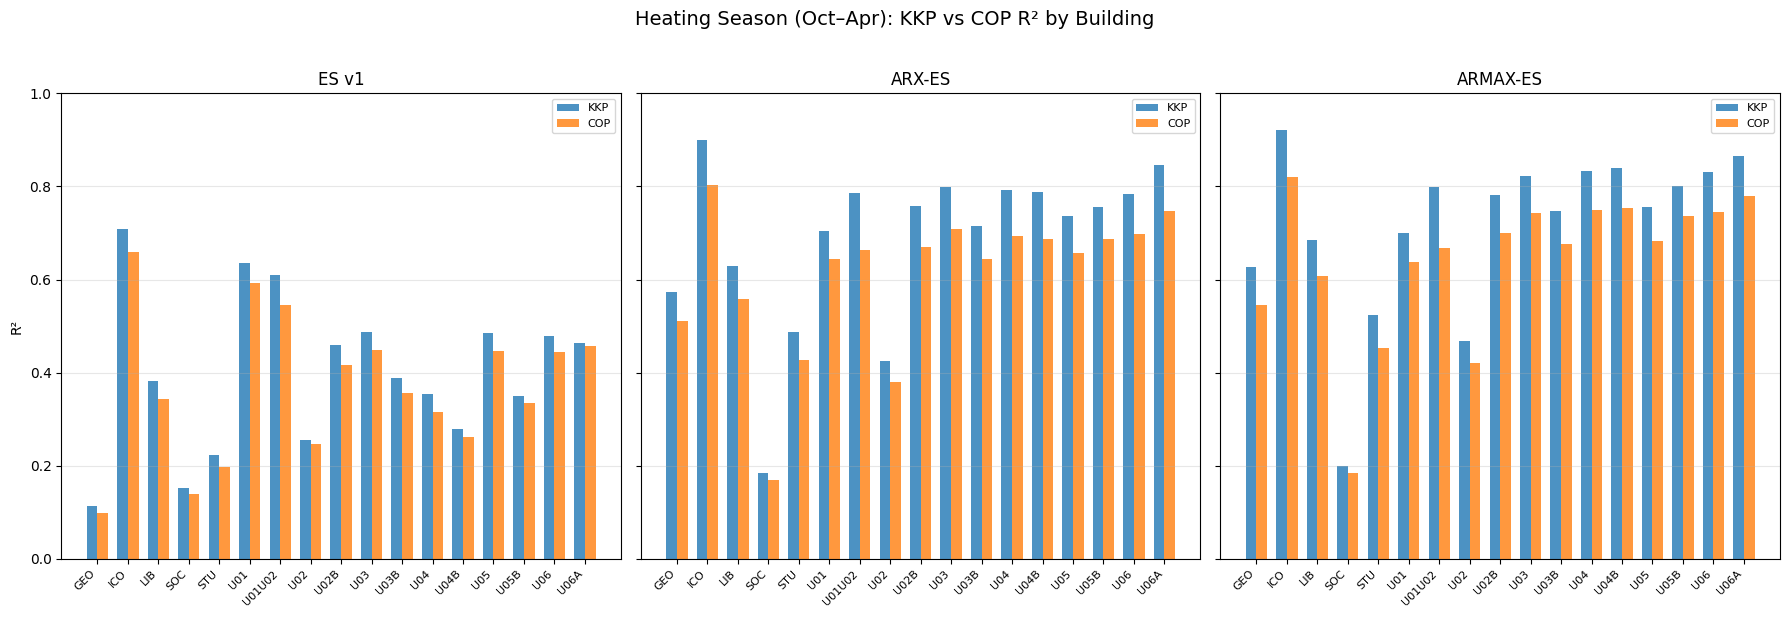

In [63]:
# ── Grouped bar chart: R² by building × model tier (heating season) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

buildings = portfolio["building"].tolist()
x = np.arange(len(buildings))
w = 0.35

for i, (tier, kkp_key, cop_key) in enumerate([
    ("ES v1", "hs_kkp_v1", "hs_cop_v1"),
    ("ARX-ES", "hs_kkp_arx", "hs_cop_arx"),
    ("ARMAX-ES", "hs_kkp_armax", "hs_cop_armax"),
]):
    ax = axes[i]
    kkp_vals = portfolio[kkp_key].values
    cop_vals = portfolio[cop_key].values
    ax.bar(x - w/2, kkp_vals, w, label="KKP", color="C0", alpha=0.8)
    ax.bar(x + w/2, cop_vals, w, label="COP", color="C1", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(buildings, rotation=45, ha="right", fontsize=8)
    ax.set_title(tier, fontsize=12)
    ax.set_ylabel("R²" if i == 0 else "")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim(0, 1)

plt.suptitle("Heating Season (Oct–Apr): KKP vs COP R² by Building", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

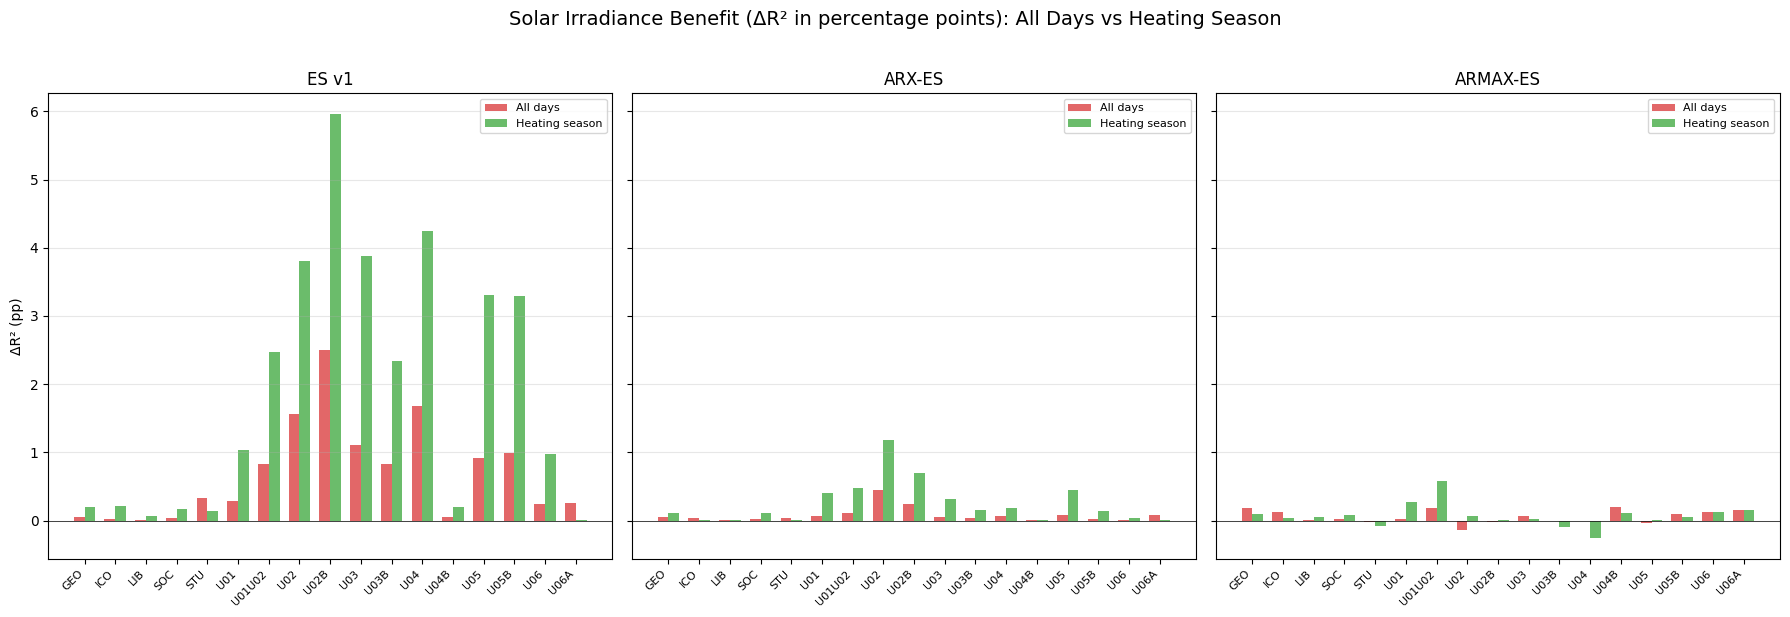

In [64]:
# ── Solar benefit bar chart: all-days vs heating season ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, tier in enumerate(["ES v1", "ARX-ES", "ARMAX-ES"]):
    ax = axes[i]
    ad_key_no = f"all_cop_v1" if tier == "ES v1" else (f"all_cop_arx" if tier == "ARX-ES" else f"all_cop_armax")
    ad_key_sol = f"all_cop_v1_solar" if tier == "ES v1" else (f"all_cop_arx_solar" if tier == "ARX-ES" else f"all_cop_armax_solar")
    hs_key_no = f"hs_cop_v1" if tier == "ES v1" else (f"hs_cop_arx" if tier == "ARX-ES" else f"hs_cop_armax")
    hs_key_sol = f"hs_cop_v1_solar" if tier == "ES v1" else (f"hs_cop_arx_solar" if tier == "ARX-ES" else f"hs_cop_armax_solar")

    ad_dr2 = (portfolio[ad_key_sol] - portfolio[ad_key_no]).values
    hs_dr2 = (portfolio[hs_key_sol] - portfolio[hs_key_no]).values

    ax.bar(x - w/2, ad_dr2 * 100, w, label="All days", color="C3", alpha=0.7)
    ax.bar(x + w/2, hs_dr2 * 100, w, label="Heating season", color="C2", alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(buildings, rotation=45, ha="right", fontsize=8)
    ax.set_title(tier, fontsize=12)
    ax.set_ylabel("ΔR² (pp)" if i == 0 else "")
    ax.axhline(0, color="k", lw=0.5)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Solar Irradiance Benefit (ΔR² in percentage points): All Days vs Heating Season",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

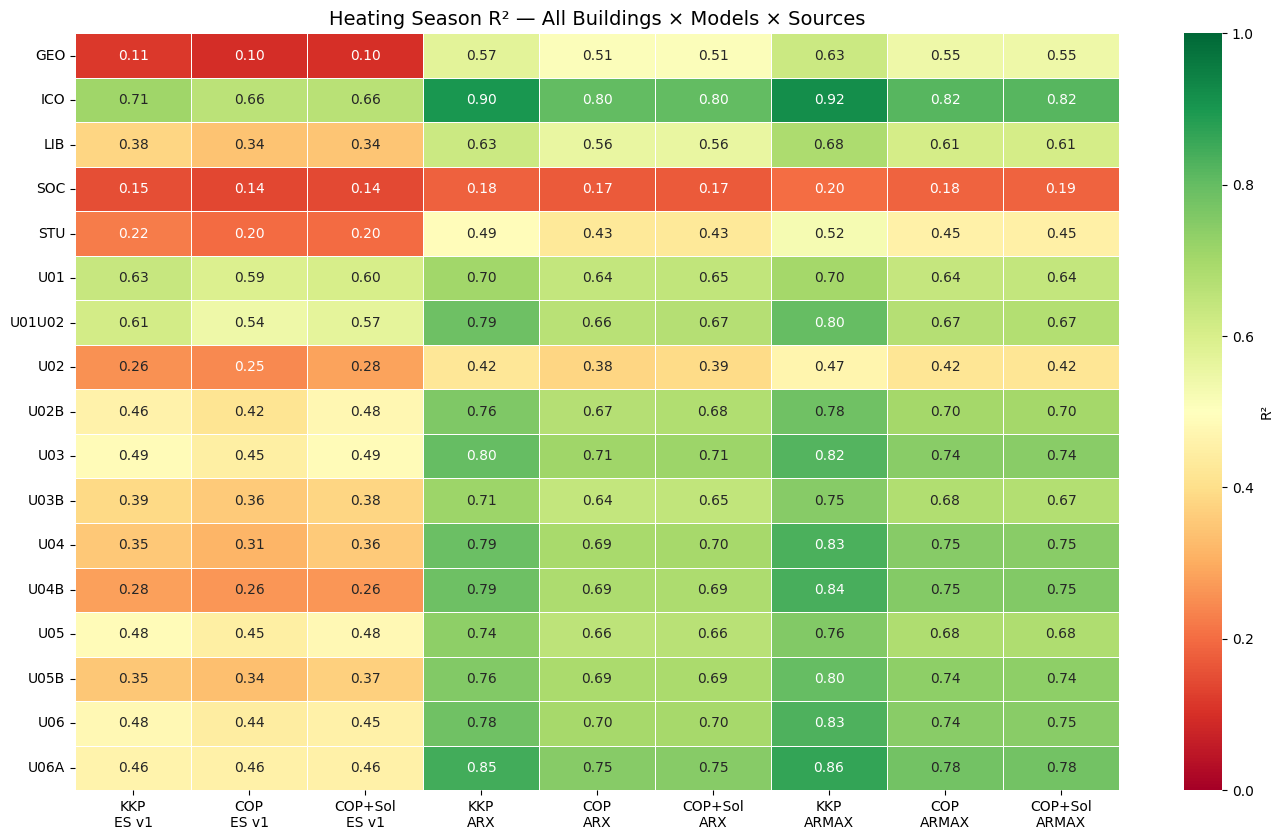

In [65]:
# ── Heatmap: R² across all buildings × models (heating season) ──
heatmap_data = portfolio.set_index("building")[[
    "hs_kkp_v1", "hs_cop_v1", "hs_cop_v1_solar",
    "hs_kkp_arx", "hs_cop_arx", "hs_cop_arx_solar",
    "hs_kkp_armax", "hs_cop_armax", "hs_cop_armax_solar",
]].rename(columns={
    "hs_kkp_v1": "KKP\nES v1", "hs_cop_v1": "COP\nES v1", "hs_cop_v1_solar": "COP+Sol\nES v1",
    "hs_kkp_arx": "KKP\nARX", "hs_cop_arx": "COP\nARX", "hs_cop_arx_solar": "COP+Sol\nARX",
    "hs_kkp_armax": "KKP\nARMAX", "hs_cop_armax": "COP\nARMAX", "hs_cop_armax_solar": "COP+Sol\nARMAX",
})

fig, ax = plt.subplots(figsize=(14, max(6, len(portfolio) * 0.5)))
im = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
                 linewidths=0.5, ax=ax, cbar_kws={"label": "R²"})
ax.set_title("Heating Season R² — All Buildings × Models × Sources", fontsize=14)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Portfolio Summary

**Key questions answered:**

1. **Does KKP consistently outperform COP?** Check the mean ΔR² across buildings. If KKP wins on average, this confirms the local-station advantage seen with U06.

2. **Is the solar benefit consistent across buildings?** Some buildings (more glass, south-facing) may benefit more from solar irradiance than others. Look for outliers in the solar ΔR² chart.

3. **Does the heating-season perspective hold across the portfolio?** If heating-season solar ΔR² is consistently larger than all-days, this validates the finding that summer dilutes the signal.

4. **Which buildings are hardest to model?** Low R² indicates buildings with unusual demand patterns (e.g., irregular occupancy, process heat, or data quality issues). These are interesting cases for deeper investigation.